In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import seaborn as sns

In [ ]:
# crawler.py
import requests, time
from datetime import date, timedelta

def fetch_day(d, token, max_retries=5):
    for attempt in range(max_retries):
        try:
            r = requests.get(
                f"https://sisteminformasibanjir.jakarta.go.id/api/report/posPengamatanReports/{d}",
                params={"format": "json"},
                headers={"token": token},
                timeout=15,
            )
            if r.status_code in (401, 403):
                raise RuntimeError(f"Token invalid (HTTP {r.status_code})")
            r.raise_for_status()
            return r.json().get("data", [])
        except RuntimeError:
            raise
        except Exception as e:
            print(f"  retry {d}: {e}")
            time.sleep(2 ** attempt)
    return None


def crawl_range(start, end, token):
    cur, last = date.fromisoformat(start), date.fromisoformat(end)
    all_rows, failed = [], []

    while cur <= last:
        d = cur.isoformat()
        print("fetch", d)
        rows = fetch_day(d, token)

        if not rows:
            failed.append(d)
        else:
            all_rows.extend(rows)

        time.sleep(0.2)
        cur += timedelta(days=1)

    return all_rows, failed

In [ ]:
# test_crawler.py
import pandas as pd

TOKEN = "T4EgIr1xIwsy7vr9UiAY64L61HWlDVN4V6qE3cc7OCvGzEg4hqhiagqatihAFgGB"

raw, failed = crawl_range("2021-01-16", "2026-08-25", TOKEN)
print(f"rows: {len(raw)}, failed: {failed}")

if raw:
    print("contoh row mentah:", raw[0])   # cek dulu apa strukturnya masih sama

    # ── flatten nested fields ────────────────────────────────────────────
    records = []
    for row in raw:
        records.append({
            "station_id"  : row["pos_pengamatan"]["id"],
            "station_name": row["pos_pengamatan"]["name"],
            "river"       : row["pos_pengamatan"]["aliran"],
            "datetime"    : row["tanggal"] + " " + row["jam"],
            "water_level" : row["ketinggian"],
            "alert_level" : row["status_siaga"],
            "weather"     : row["cuaca"]["nama"],
        })

    df = pd.DataFrame(records)
    df["station_id"]  = df["station_id"].astype(int)
    df["water_level"] = pd.to_numeric(df["water_level"], errors="coerce")
    df["alert_level"] = pd.to_numeric(df["alert_level"], errors="coerce").astype("Int64")
    df["datetime"]    = pd.to_datetime(df["datetime"], errors="coerce")

    df = (df
          .drop_duplicates(subset=["station_id", "datetime"])
          .sort_values(["datetime", "station_id"])
          .reset_index(drop=True))

    print(df.shape)
    display(df.head())
else:
    print("Masih kosong — coba print raw response manual (lihat instruksi di bawah)")

fetch 2021-01-16
fetch 2021-01-17
fetch 2021-01-18
fetch 2021-01-19
fetch 2021-01-20
fetch 2021-01-21
fetch 2021-01-22
fetch 2021-01-23
fetch 2021-01-24
fetch 2021-01-25
fetch 2021-01-26
fetch 2021-01-27
fetch 2021-01-28
fetch 2021-01-29
fetch 2021-01-30
fetch 2021-01-31
fetch 2021-02-01
fetch 2021-02-02
fetch 2021-02-03
fetch 2021-02-04
fetch 2021-02-05
fetch 2021-02-06
fetch 2021-02-07
fetch 2021-02-08
fetch 2021-02-09
fetch 2021-02-10
fetch 2021-02-11
fetch 2021-02-12
fetch 2021-02-13
fetch 2021-02-14
fetch 2021-02-15
fetch 2021-02-16
fetch 2021-02-17
fetch 2021-02-18
fetch 2021-02-19
fetch 2021-02-20
fetch 2021-02-21
fetch 2021-02-22
fetch 2021-02-23
fetch 2021-02-24
fetch 2021-02-25
fetch 2021-02-26
fetch 2021-02-27
fetch 2021-02-28
fetch 2021-03-01
fetch 2021-03-02
fetch 2021-03-03
fetch 2021-03-04
fetch 2021-03-05
fetch 2021-03-06
fetch 2021-03-07
fetch 2021-03-08
fetch 2021-03-09
fetch 2021-03-10
fetch 2021-03-11
fetch 2021-03-12
fetch 2021-03-13
fetch 2021-03-14
fetch 2021-03-

,station_id,station_name,river,datetime,water_level,alert_level,weather
0,1,Pos Depok,Aliran Tengah,2021-01-16,90,4,Mendung Tipis
1,2,Pos Pesanggrahan,Aliran Barat,2021-01-16,55,4,Mendung Tipis
2,3,Pos Angke Hulu,Aliran Barat,2021-01-16,40,4,Terang
3,4,Pos Krukut Hulu,Aliran Tengah,2021-01-16,10,4,Mendung Tipis
4,5,Pos Cipinang Hulu,Aliran Timur,2021-01-16,75,4,Mendung Tipis


In [ ]:
# First 5 rows of df
df.head()

,station_id,station_name,river,datetime,water_level,alert_level,weather
0,1,Pos Depok,Aliran Tengah,2021-01-16,90,4,Mendung Tipis
1,2,Pos Pesanggrahan,Aliran Barat,2021-01-16,55,4,Mendung Tipis
2,3,Pos Angke Hulu,Aliran Barat,2021-01-16,40,4,Terang
3,4,Pos Krukut Hulu,Aliran Tengah,2021-01-16,10,4,Mendung Tipis
4,5,Pos Cipinang Hulu,Aliran Timur,2021-01-16,75,4,Mendung Tipis


In [ ]:
# Info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370838 entries, 0 to 370837
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   station_id    370838 non-null  int64         
 1   station_name  370838 non-null  object        
 2   river         370838 non-null  object        
 3   datetime      370838 non-null  datetime64[ns]
 4   water_level   370838 non-null  int64         
 5   alert_level   370838 non-null  Int64         
 6   weather       370838 non-null  object        
dtypes: Int64(1), datetime64[ns](1), int64(2), object(3)
memory usage: 20.2+ MB


After looking at the data in high level, problems with the data can be identified :     
- Datetime is still labeled as pandas object -> change to pandas Datetime
- Data is not sorted (considering this is time series data, order is very important)
- Some duplicates can be found -> clean this

In [ ]:
# Basic consistency Cleaning
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.sort_values(['station_name', 'datetime'])
df = df.drop_duplicates(subset=['station_name', 'datetime'])

# 1. Timestamp Standardization

---

Flow in this section :    
- Compute delta (time interval) in this section, find out the time variation for each station -> best to plot it as well
- Standardize the time intervals and sort by station for checks

In [ ]:
# Find time difference for each station_name
df['delta'] = df.groupby('station_name')['datetime'].diff()
df['delta_mnt'] = df['delta'].dt.total_seconds() / 60

In [ ]:
df.groupby('station_name')['delta_mnt'].agg(['mean', 'median', 'std', 'max'])

,mean,median,std,max
station_name,,,,
Bendung Katulampa,62.651463,60.0,23.517653,1418.0
Pos Angke Hulu,61.970791,60.0,20.794797,1418.0
Pos Cipinang Hulu,68.802160,60.0,45.504303,1419.0
Pos Depok,62.066000,60.0,21.041238,1419.0
Pos Krukut Hulu,62.502745,60.0,21.860788,1418.0
Pos Pesanggrahan,62.770125,60.0,23.455838,1419.0
Pos Sunter Hulu,64.754337,60.0,27.339440,1418.0
Waduk Pluit,63.928048,60.0,30.699413,1418.0


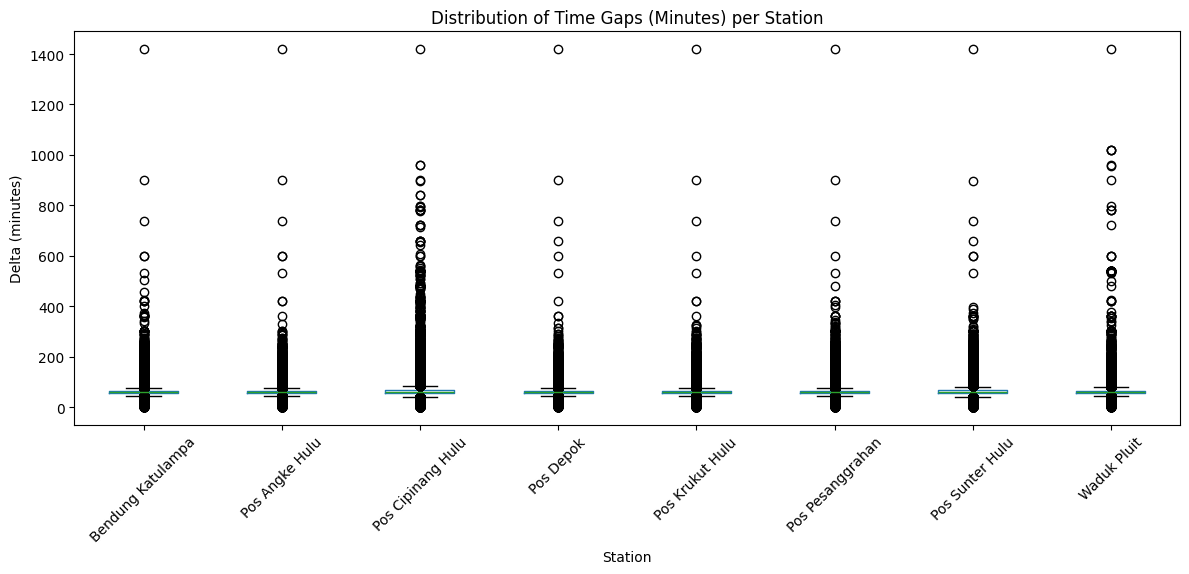

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(
    column='delta_mnt',
    by='station_name',
    ax=ax,
    grid=False
)

# Clean up auto title
plt.suptitle('')
ax.set_title('Distribution of Time Gaps (Minutes) per Station')

# Labels
ax.set_xlabel('Station')
ax.set_ylabel('Delta (minutes)')

# Rotate for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Data is mostly centralized around hourly data, so we will be generalizing to make all timestamps follow the 1 hour rule.

> For data that has large gaps (e.g. 1418-minute anomaly), a process of interpolation will be enforced in order to abolish any NAs.

In [ ]:
df_resampled = (
    df.set_index('datetime')
      .groupby('station_name')
      .resample('1H')
      .agg({
          'water_level': 'mean',
          'alert_level': 'max'
      })
      .reset_index()
)

/tmp/ipykernel_711/3430768690.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


In [ ]:
meta = df[['station_name', 'river']].drop_duplicates()
metadata = df_resampled.merge(meta, on='station_name', how='left')

In [ ]:
metadata

,station_name,datetime,water_level,alert_level,river
0,Bendung Katulampa,2021-01-16 00:00:00,20.0,4,Aliran Tengah
1,Bendung Katulampa,2021-01-16 01:00:00,20.0,4,Aliran Tengah
2,Bendung Katulampa,2021-01-16 02:00:00,20.0,4,Aliran Tengah
3,Bendung Katulampa,2021-01-16 03:00:00,20.0,4,Aliran Tengah
4,Bendung Katulampa,2021-01-16 04:00:00,20.0,4,Aliran Tengah
...,...,...,...,...,...
393163,Waduk Pluit,2026-08-25 19:00:00,-175.0,4,Aliran Tengah
393164,Waduk Pluit,2026-08-25 20:00:00,-180.0,4,Aliran Tengah
393165,Waduk Pluit,2026-08-25 21:00:00,-180.0,4,Aliran Tengah
393166,Waduk Pluit,2026-08-25 22:00:00,-180.0,4,Aliran Tengah


In [ ]:
# Resampled Data NA Checking
metadata.isna().sum()

,0
station_name,0
datetime,0
water_level,24786
alert_level,24786
river,0


# 2. Timestamp Consistency Checks
---

In [ ]:
# missing ratio
missing_ratio = metadata['water_level'].isna().mean()

# duplicates
dup = metadata.duplicated(['station_name', 'datetime']).sum()

print(f'Missing Ratio: {missing_ratio}')
print(f'Duplicates: {dup}')

Missing Ratio: 0.0630417531436943
Duplicates: 0


In [ ]:
# timsetamp interval
metadata['delta'] = metadata.groupby('station_name')['datetime'].diff()
metadata['delta_mnt'] = metadata['delta'].dt.total_seconds() / 60


# Time Interval Variation (fixed)
metadata.groupby('station_name')['delta_mnt'].agg(['mean', 'median', 'std', 'max'])

,mean,median,std,max
station_name,,,,
Bendung Katulampa,60.0,60.0,0.0,60.0
Pos Angke Hulu,60.0,60.0,0.0,60.0
Pos Cipinang Hulu,60.0,60.0,0.0,60.0
Pos Depok,60.0,60.0,0.0,60.0
Pos Krukut Hulu,60.0,60.0,0.0,60.0
Pos Pesanggrahan,60.0,60.0,0.0,60.0
Pos Sunter Hulu,60.0,60.0,0.0,60.0
Waduk Pluit,60.0,60.0,0.0,60.0


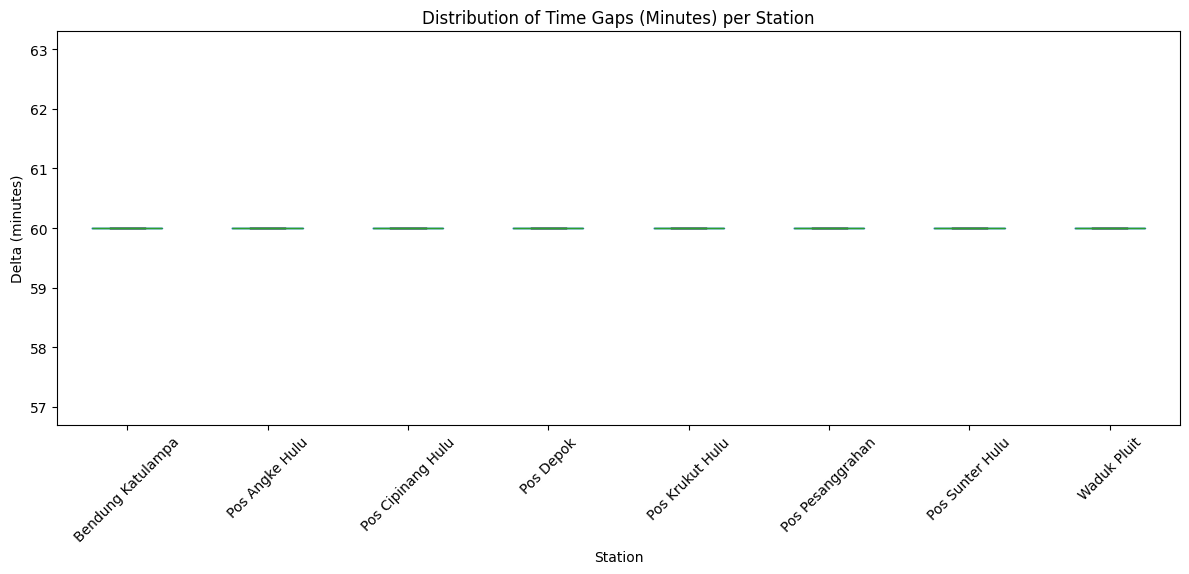

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

metadata.boxplot(
    column='delta_mnt',
    by='station_name',
    ax=ax,
    grid=False
)

# Clean up auto title
plt.suptitle('')
ax.set_title('Distribution of Time Gaps (Minutes) per Station')

# Labels
ax.set_xlabel('Station')
ax.set_ylabel('Delta (minutes)')

# Rotate for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Station Consistency Checks
---


In [ ]:
missing_ratio_stats = metadata.groupby('station_name').agg(
    count=('water_level', 'count'),
    missing_ratio=('water_level', lambda x: x.isna().mean())
)

missing_ratio_stats

,count,missing_ratio
station_name,,
Bendung Katulampa,46715,0.049581
Pos Angke Hulu,47292,0.037842
Pos Cipinang Hulu,42581,0.133687
Pos Depok,47173,0.040263
Pos Krukut Hulu,46918,0.045451
Pos Pesanggrahan,46651,0.050883
Pos Sunter Hulu,45214,0.080119
Waduk Pluit,45838,0.066512


In [ ]:
stats_sorted = missing_ratio_stats.sort_values('missing_ratio', ascending=False)

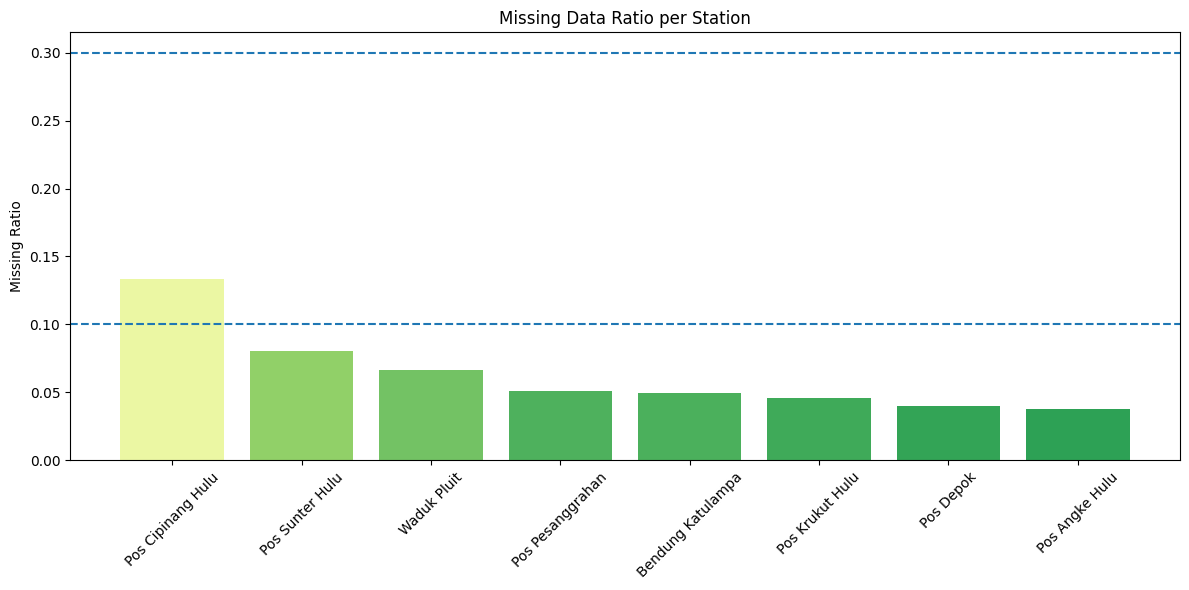

In [ ]:
norm = plt.Normalize(0, 0.3)
colors = cm.RdYlGn_r(norm(stats_sorted['missing_ratio']))

plt.figure(figsize=(12,6))
plt.bar(stats_sorted.index, stats_sorted['missing_ratio'], color=colors)

plt.xticks(rotation=45)
plt.ylabel('Missing Ratio')
plt.title('Missing Data Ratio per Station')

plt.axhline(0.1, linestyle='--')
plt.axhline(0.3, linestyle='--')

plt.tight_layout()
plt.show()

---
## Key Observations
---
- Overall data quality is good -> All stations have missing ratios below 15%, indicating relatively complete time series.

- Highest missing ratio: Pos Cipinang Hulu (~14%) -> falls within the warning range (0.1-0.3) requires attention but still usable with proper imputation

- All other stations < 10% missing -> Categorized as good quality, suitable for modeling with minimal preprocessing

- No station exceeds 30% threshold -> No stations are considered critical / unusable

---

## Implications

---
No station needs to be dropped at this stage

Missing values can be handled via:
- interpolation (for short gaps)
- forward fill with limits

Special attention should be given to Pos Cipinang Hulu due to relatively higher missingness

In [ ]:
# Time Coverage
metadata.groupby('station_name')['datetime'].agg(['min', 'max'])

,min,max
station_name,,
Bendung Katulampa,2021-01-16,2026-08-25 23:00:00
Pos Angke Hulu,2021-01-16,2026-08-25 23:00:00
Pos Cipinang Hulu,2021-01-16,2026-08-25 23:00:00
Pos Depok,2021-01-16,2026-08-25 23:00:00
Pos Krukut Hulu,2021-01-16,2026-08-25 23:00:00
Pos Pesanggrahan,2021-01-16,2026-08-25 23:00:00
Pos Sunter Hulu,2021-01-16,2026-08-25 23:00:00
Waduk Pluit,2021-01-18,2026-08-25 23:00:00


Already standardized, good to go.

# 4. Outlier Detection

---

Flow :
- Visualisasi time series water level per pos

- Deteksi outlier menggunakan: IQR, Z-score, anomaly pada spike level

- Tandai outlier untuk cleaning

In [ ]:
g = metadata.groupby('station_name')

# --- IQR (robust to skew) ---
q1 = g['water_level'].transform(lambda x: x.quantile(0.25))
q3 = g['water_level'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

metadata['outlier_iqr'] = (
    (metadata['water_level'] < q1 - 1.5*iqr) |
    (metadata['water_level'] > q3 + 1.5*iqr)
)

# --- Z-score (good for near-normal segments) ---
mean = g['water_level'].transform('mean')
std  = g['water_level'].transform('std')

metadata['zscore'] = (metadata['water_level'] - mean) / std
metadata['outlier_z'] = metadata['zscore'].abs() > 3

# --- Spike detector (temporal jumps) ---
# captures sudden changes between consecutive timestamps
metadata['delta'] = g['water_level'].diff()

# robust threshold using MAD of deltas per station
def mad(x):
    med = np.nanmedian(x)
    return np.nanmedian(np.abs(x - med))

delta_med = g['delta'].transform('median')
delta_mad = g['delta'].transform(mad)

# avoid division by zero
delta_mad = delta_mad.replace(0, np.nan)

metadata['outlier_physical'] = (
    (metadata['water_level'] < -50) |
    (metadata['delta'].abs() > 50)
)

In [ ]:
metadata['outlier_any'] = (
    metadata['outlier_iqr'] |
    metadata['outlier_z'] |
    metadata['outlier_physical']
)

In [ ]:
outlier_stats = metadata.groupby('station_name')[[
    'outlier_iqr','outlier_z','outlier_physical','outlier_any'
]].mean().sort_values('outlier_any', ascending=False)

outlier_stats

,outlier_iqr,outlier_z,outlier_physical,outlier_any
station_name,,,,
Waduk Pluit,0.027981,0.005295,0.932042,0.933488
Bendung Katulampa,0.092997,0.013326,0.002930,0.093730
Pos Sunter Hulu,0.084513,0.021281,0.005127,0.085531
Pos Angke Hulu,0.081807,0.022847,0.006022,0.084920
Pos Cipinang Hulu,0.069275,0.022400,0.002686,0.069906
Pos Krukut Hulu,0.055644,0.021729,0.003459,0.056437
Pos Pesanggrahan,0.053446,0.023031,0.002828,0.053975
Pos Depok,0.042542,0.013529,0.006836,0.044332


In [ ]:
def plot_station(metadata, station, window=6):
    subset = metadata[metadata['station_name'] == station].copy()

    # smoothing
    subset['smooth'] = subset['water_level'].rolling(window).mean()

    plt.figure(figsize=(14,5))

    # raw signal (faded)
    plt.plot(
        subset['datetime'],
        subset['water_level'],
        color="black",
        alpha=0.3,
        linewidth=1
    )

    # smoothed signal (main)
    plt.plot(
        subset['datetime'],
        subset['smooth'],
        linewidth=2,
        label='Smoothed'
    )

    # highlight outliers if exists
    if 'outlier_any' in subset.columns:
        mask = subset['outlier_any']
        plt.scatter(
            subset['datetime'][mask],
            subset['water_level'][mask],
            color='red',
            s=12,
            label='Outlier'
        )

    plt.title(f'Water Level - {station}')
    plt.xlabel('Datetime')
    plt.ylabel('Water Level')

    plt.legend()
    plt.tight_layout()
    plt.show()

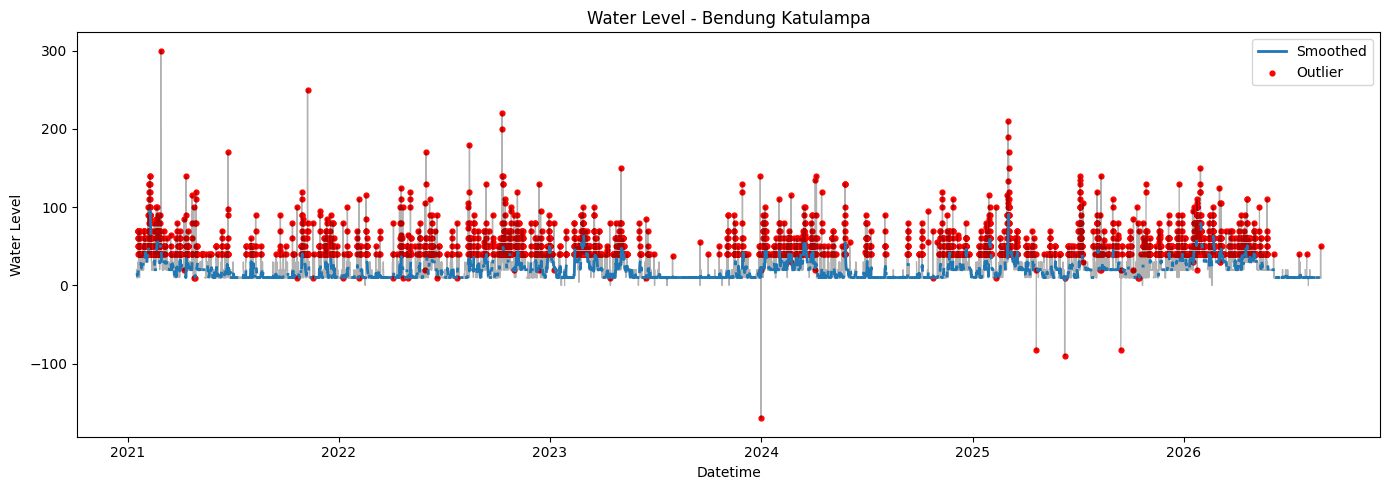

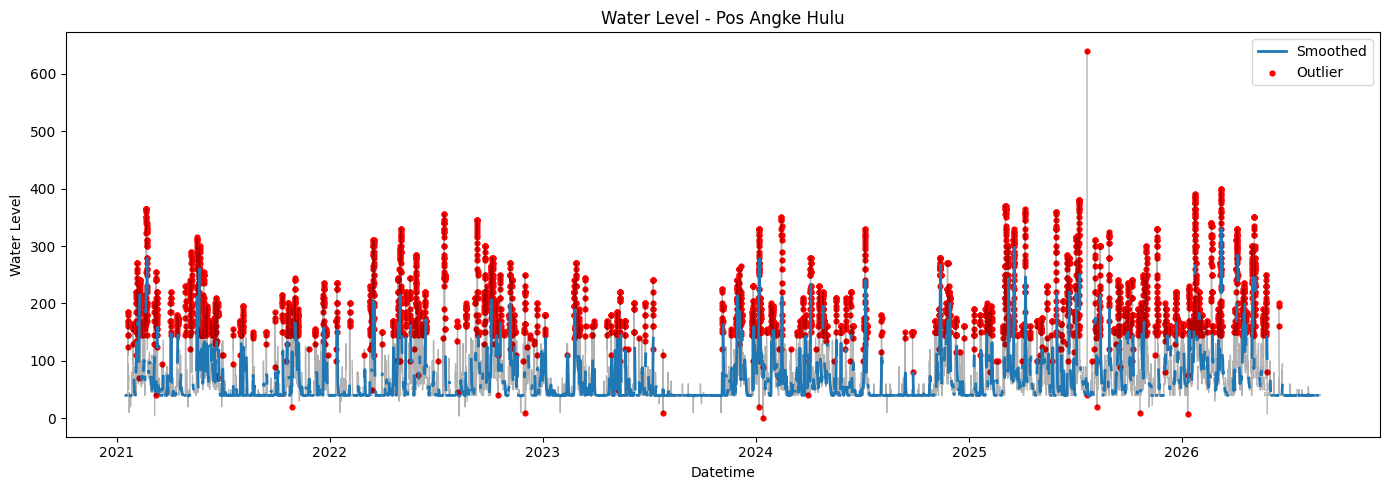

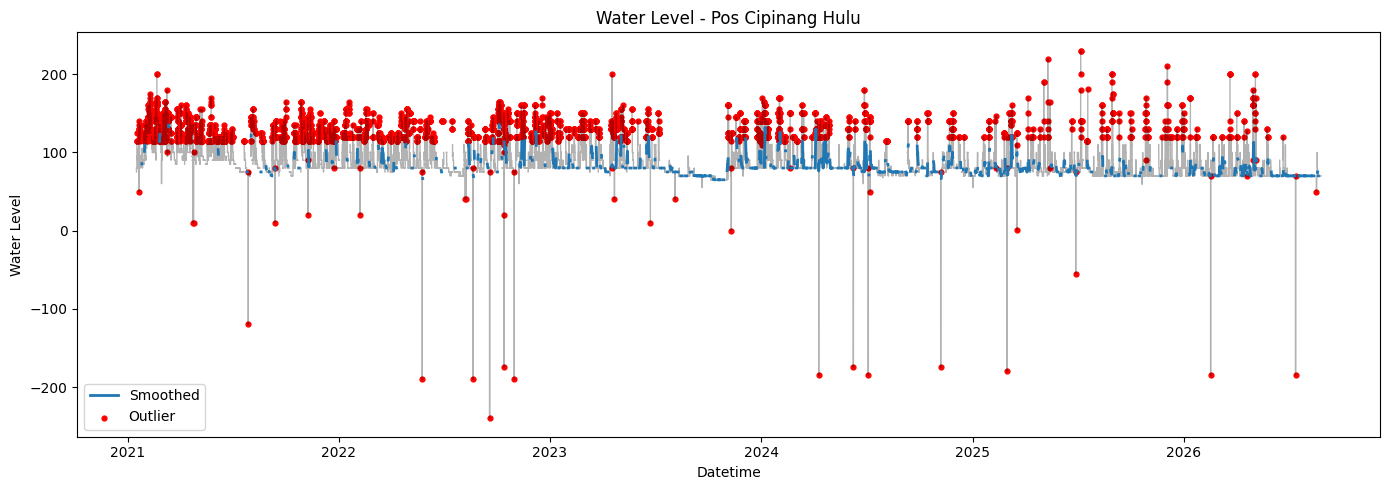

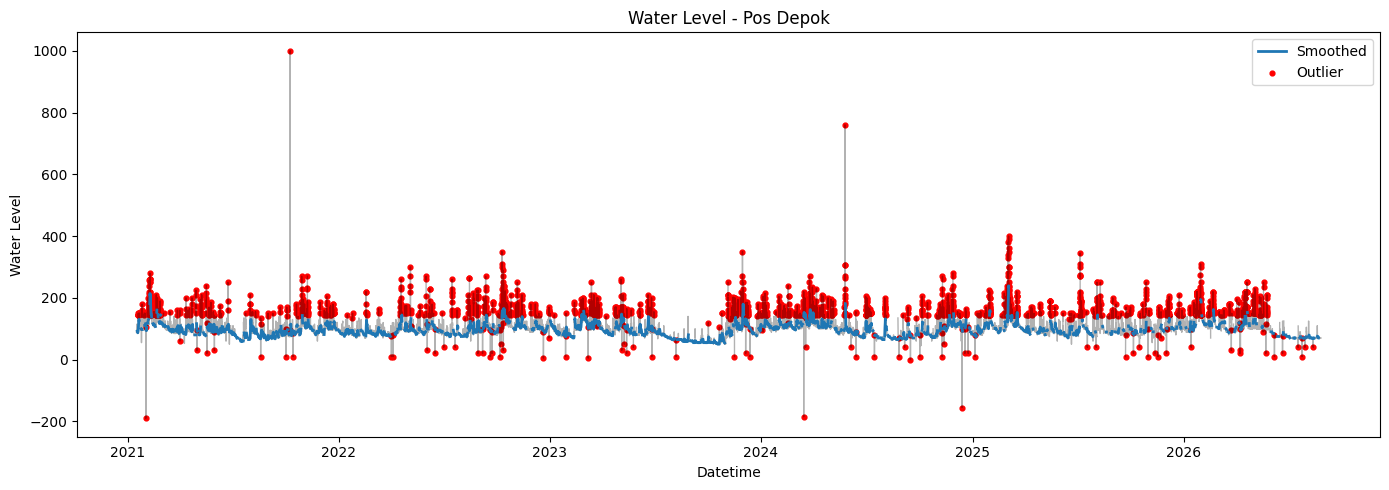

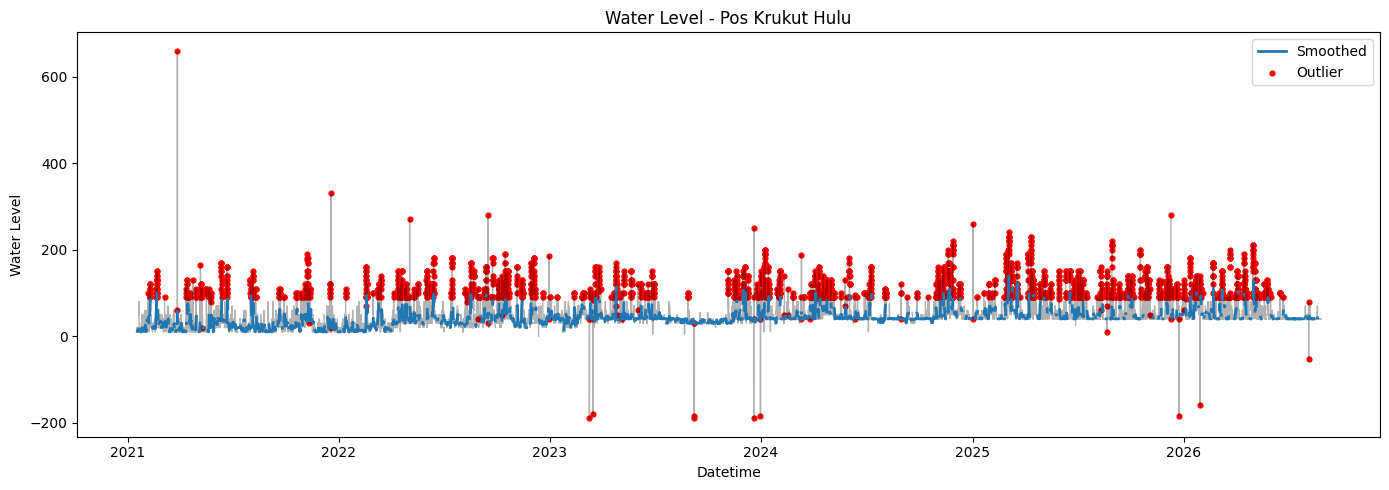

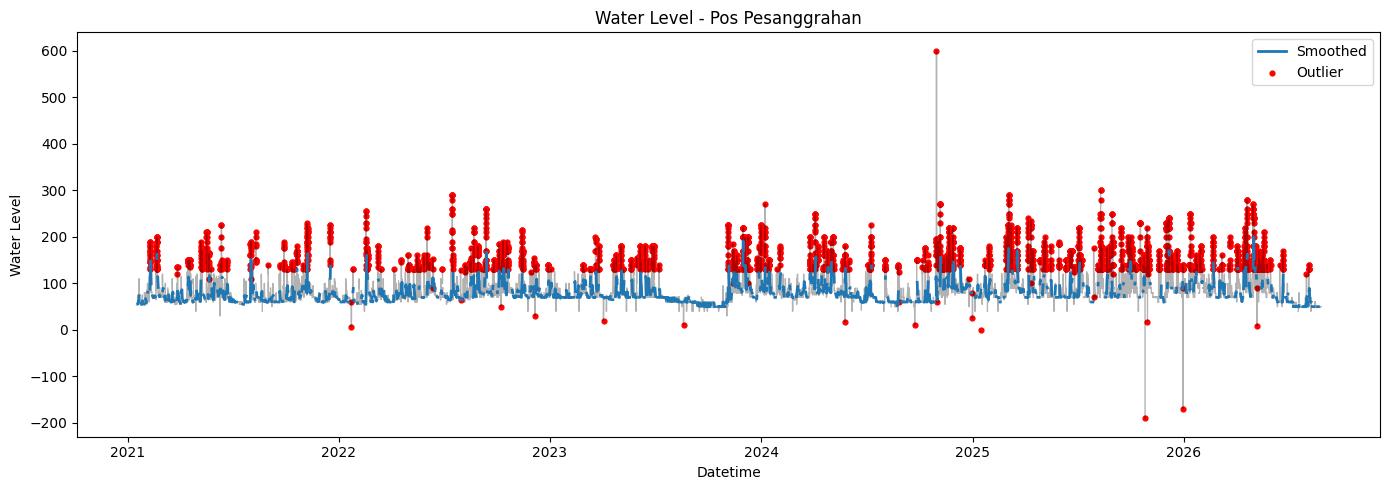

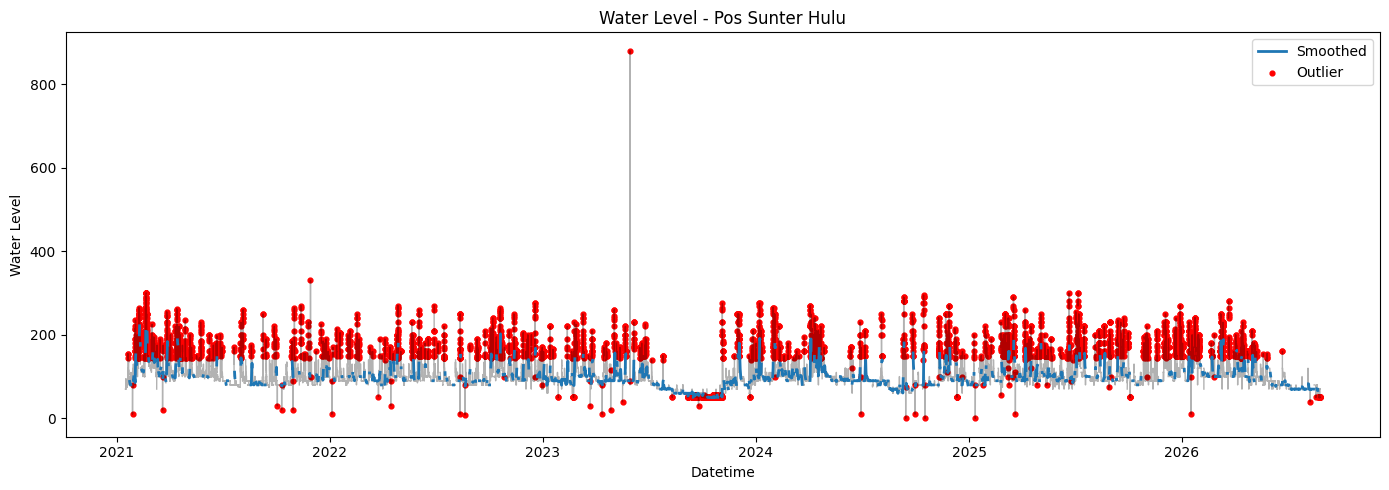

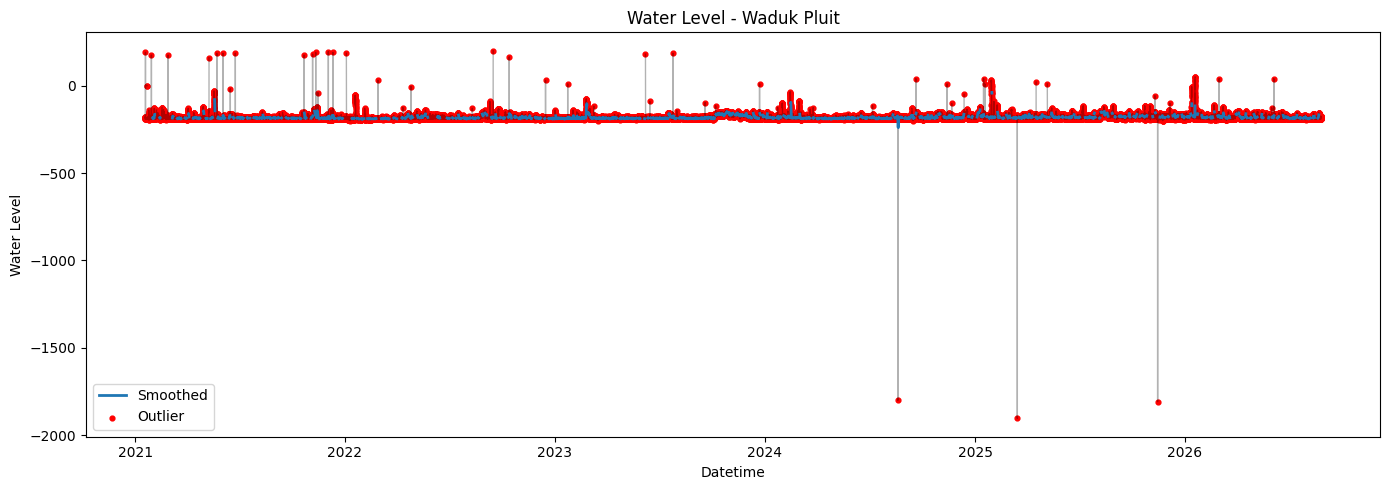

In [ ]:
for station in metadata['station_name'].unique():
    plot_station(metadata, station, window=30)

# 5. Outlier Handling

---

In [ ]:
from IPython.core.interactiveshell import default_banner
df = metadata.copy()

# Isolated Spikes
def is_isolated(flag):
    return (
        flag &
        ~flag.shift(1).fillna(False) &
        ~flag.shift(-1).fillna(False)
    )

df["isolated_spike"] = df.groupby("station_name")["outlier_physical"].transform(is_isolated)

/tmp/ipykernel_711/283219129.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~flag.shift(1).fillna(False) &
/tmp/ipykernel_711/283219129.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~flag.shift(-1).fillna(False)


In [ ]:
df["water_level_clean"] = df["water_level"]
df.loc[df['isolated_spike'], 'water_level_clean'] = np.nan

In [ ]:
df['water_level_clean'] = (
    df.groupby('station_name')['water_level_clean']
    .transform(lambda x: x.interpolate(limit=3))
)

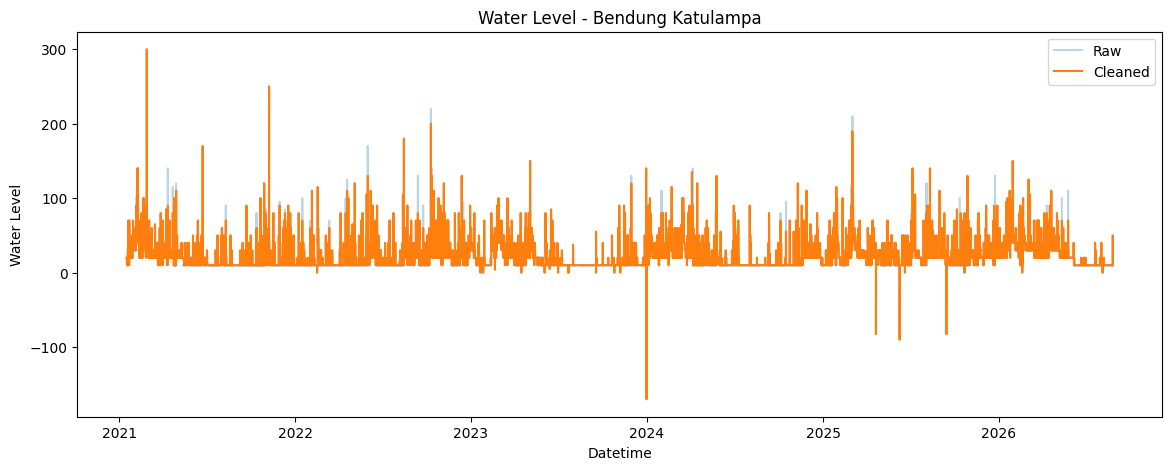

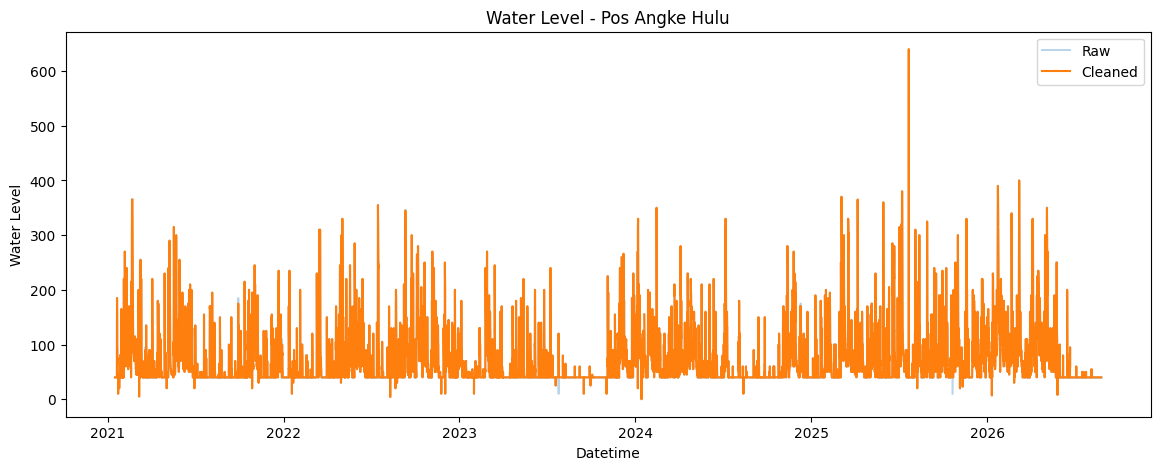

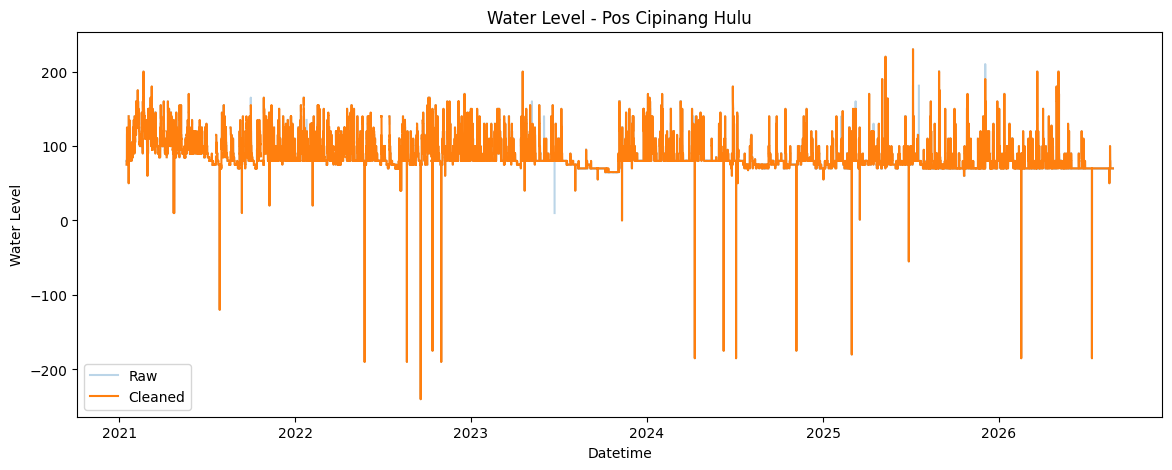

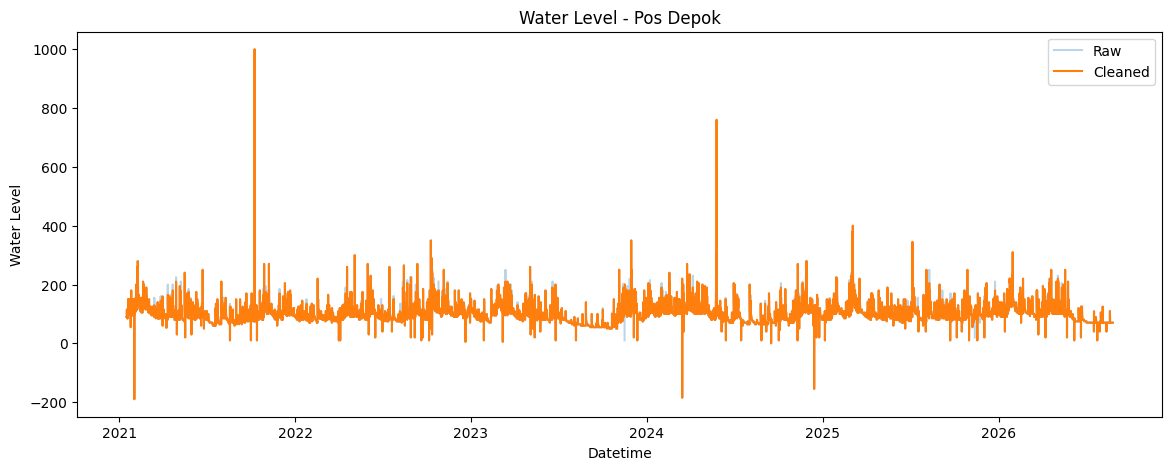

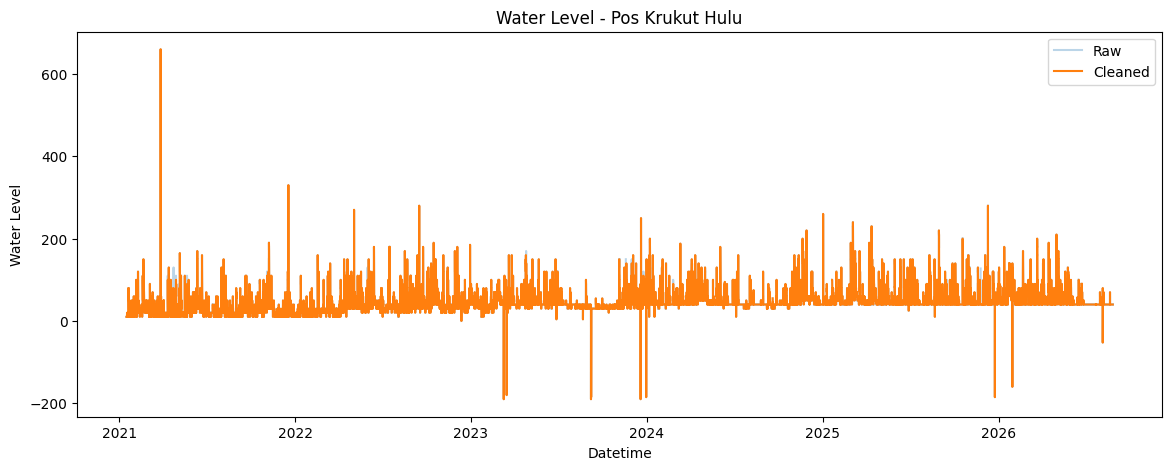

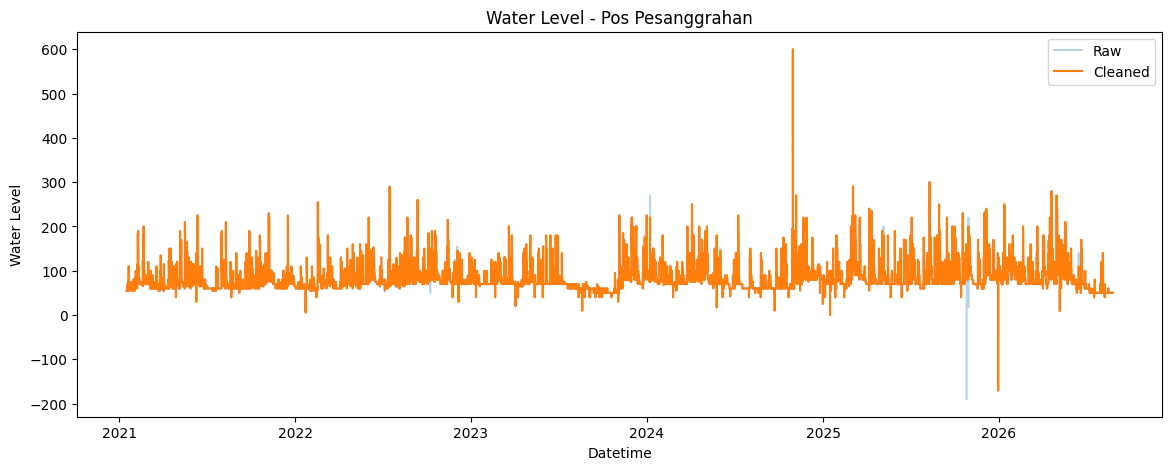

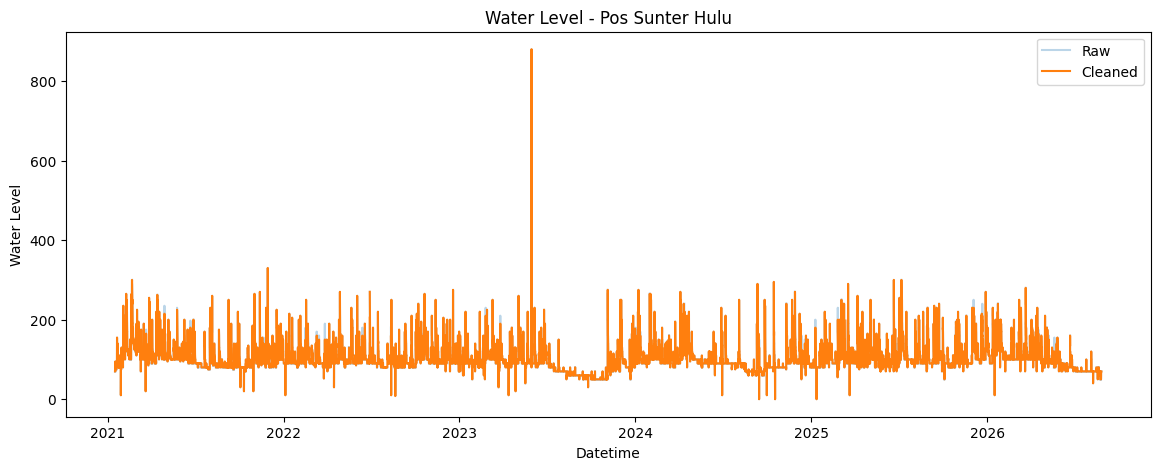

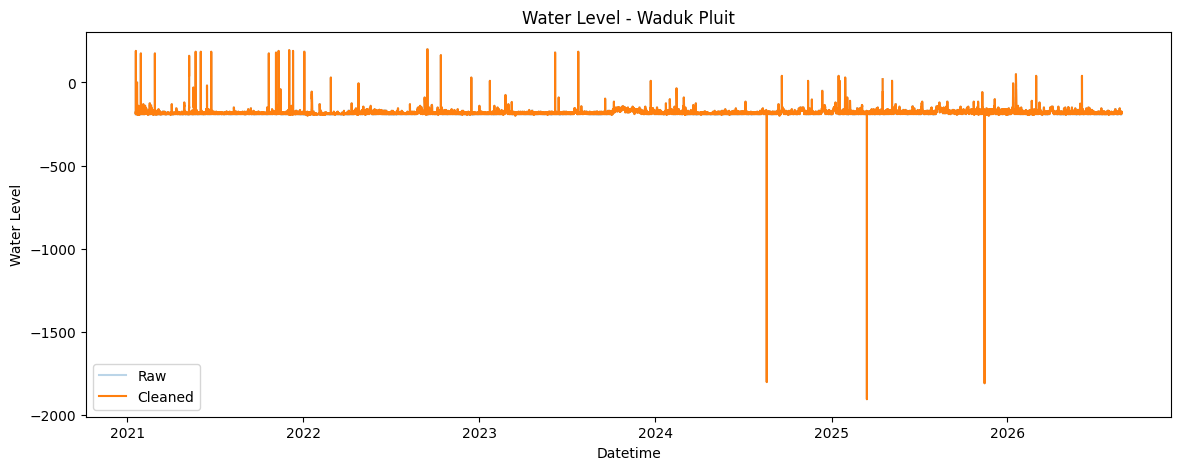

In [ ]:
for station in df['station_name'].unique():
  subset = df[df['station_name'] == station]

  # Plot
  plt.figure(figsize=(14,5))
  plt.plot(subset['datetime'], subset['water_level'], alpha=0.3)
  plt.plot(subset['datetime'], subset['water_level_clean'])

  plt.title(f'Water Level - {station}')
  plt.xlabel('Datetime')
  plt.ylabel('Water Level')
  plt.legend(['Raw', 'Cleaned'])
  plt.show()

# Data Restructuring

In [ ]:
# copy dulu supaya aman
df_clean = metadata.copy()

# pastikan tidak ada duplicate (penting sebelum pivot)
df_clean = df_clean.drop_duplicates(subset=['datetime', 'station_name'])

# pivot long → wide
df_wide = (
    df_clean
    .pivot(index='datetime', columns='station_name', values='water_level')
    .sort_index()
)

df_wide = df_wide.asfreq('1H')

print("=== HEAD DATA (df_wide) ===")
display(df_wide.head())

print("\n=== SHAPE DATA ===")
print(f"Rows: {df_wide.shape[0]:,}")
print(f"Columns (Stations): {df_wide.shape[1]}")

print("\n=== MISSING VALUE PER STATION ===")
missing = df_wide.isna().sum().sort_values(ascending=False)

display(missing.to_frame(name='missing_count'))

print("\n=== MISSING RATIO (%) ===")
missing_ratio = (df_wide.isna().mean() * 100).sort_values(ascending=False)

display(missing_ratio.to_frame(name='missing_%').round(2))

=== HEAD DATA (df_wide) ===


/tmp/ipykernel_711/3761411775.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_wide = df_wide.asfreq('1H')


station_name,Bendung Katulampa,Pos Angke Hulu,Pos Cipinang Hulu,Pos Depok,Pos Krukut Hulu,Pos Pesanggrahan,Pos Sunter Hulu,Waduk Pluit
datetime,,,,,,,,
2021-01-16 00:00:00,20.0,40.0,75.0,90.0,10.0,55.0,70.0,NaN
2021-01-16 01:00:00,20.0,40.0,80.0,90.0,10.0,55.0,NaN,NaN
2021-01-16 02:00:00,20.0,40.0,80.0,90.0,10.0,55.0,70.0,NaN
2021-01-16 03:00:00,20.0,40.0,NaN,90.0,10.0,55.0,NaN,NaN
2021-01-16 04:00:00,20.0,40.0,80.0,90.0,10.0,55.0,70.0,NaN



=== SHAPE DATA ===
Rows: 49,152
Columns (Stations): 8

=== MISSING VALUE PER STATION ===


,missing_count
station_name,
Pos Cipinang Hulu,6571
Pos Sunter Hulu,3938
Waduk Pluit,3314
Pos Pesanggrahan,2501
Bendung Katulampa,2437
Pos Krukut Hulu,2234
Pos Depok,1979
Pos Angke Hulu,1860



=== MISSING RATIO (%) ===


,missing_%
station_name,
Pos Cipinang Hulu,13.37
Pos Sunter Hulu,8.01
Waduk Pluit,6.74
Pos Pesanggrahan,5.09
Bendung Katulampa,4.96
Pos Krukut Hulu,4.55
Pos Depok,4.03
Pos Angke Hulu,3.78


# Missing Value Handling

In [ ]:
df = df_wide.copy()

In [ ]:
print("\n=== MISSING SEBELUM CLEANING ===")

missing_count = df.isna().sum().sort_values(ascending=False)
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)

display(missing_count.to_frame(name='missing_count'))
display(missing_ratio.to_frame(name='missing_%').round(2))


=== MISSING SEBELUM CLEANING ===


,missing_count
station_name,
Pos Cipinang Hulu,6571
Pos Sunter Hulu,3938
Waduk Pluit,3314
Pos Pesanggrahan,2501
Bendung Katulampa,2437
Pos Krukut Hulu,2234
Pos Depok,1979
Pos Angke Hulu,1860


,missing_%
station_name,
Pos Cipinang Hulu,13.37
Pos Sunter Hulu,8.01
Waduk Pluit,6.74
Pos Pesanggrahan,5.09
Bendung Katulampa,4.96
Pos Krukut Hulu,4.55
Pos Depok,4.03
Pos Angke Hulu,3.78


DISTRIBUSI PANJANG GAP PER STASIUN (sebelum imputasi)


,Total Gap Event,Gap ≤ 6j (dapat diisi),Gap > 6j (dibiarkan NaN),Panjang Gap Maks (jam),Panjang Gap Median (jam)
Stasiun,,,,,
Bendung Katulampa,1842,1835,7,22,1.0
Pos Angke Hulu,1536,1530,6,22,1.0
Pos Cipinang Hulu,3356,3240,116,22,1.0
Pos Depok,1663,1657,6,22,1.0
Pos Krukut Hulu,1834,1829,5,22,1.0
Pos Pesanggrahan,1885,1879,6,22,1.0
Pos Sunter Hulu,2995,2988,7,22,1.0
Waduk Pluit,2232,2172,60,48,1.0


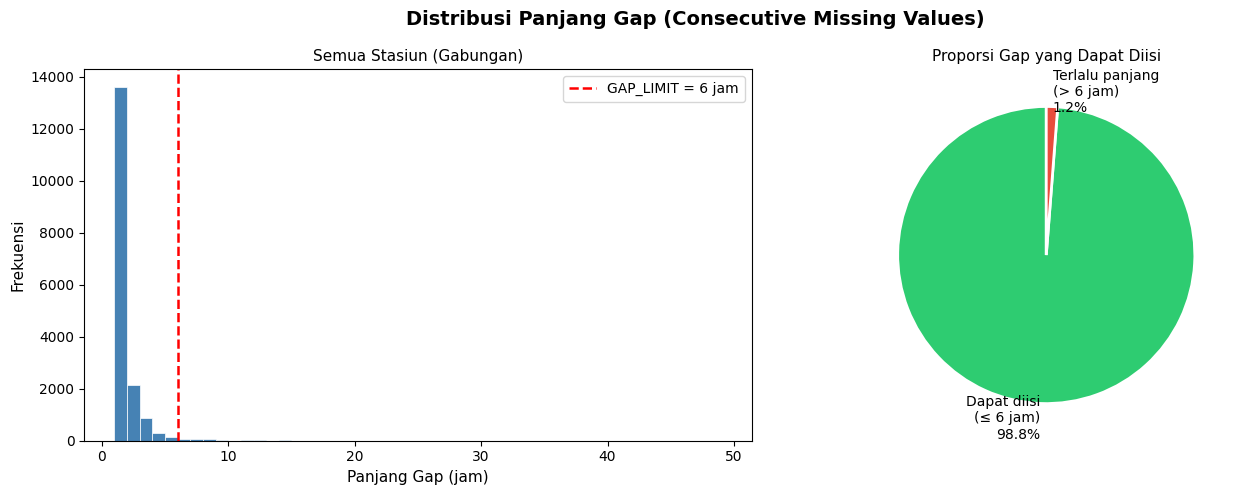


Kesimpulan: 98.8% dari seluruh gap event memiliki panjang ≤ 6 jam dan dapat diisi melalui interpolasi.
Pilihan GAP_LIMIT=6 jam mampu menangani sebagian besar kejadian missing tanpa risiko over-imputation.


In [ ]:
def get_gap_lengths(series):
    """
    Hitung panjang setiap run of consecutive NaN dalam sebuah Series.
    Return: list of int (panjang gap dalam timesteps/jam)
    """
    gap_lengths = []
    count = 0
    for val in series:
        if pd.isna(val):
            count += 1
        else:
            if count > 0:
                gap_lengths.append(count)
                count = 0
    if count > 0:
        gap_lengths.append(count)
    return gap_lengths


print("=" * 60)
print("DISTRIBUSI PANJANG GAP PER STASIUN (sebelum imputasi)")
print("=" * 60)

GAP_LIMIT = 6  # sesuaikan dengan nilai di notebook asli

all_gaps = {}
gap_summary_rows = []

for station in df_wide.columns:
    gaps = get_gap_lengths(df_wide[station])
    all_gaps[station] = gaps

    total_gaps   = len(gaps)
    gaps_short   = sum(1 for g in gaps if g <= GAP_LIMIT)
    gaps_long    = sum(1 for g in gaps if g > GAP_LIMIT)
    max_gap      = max(gaps) if gaps else 0
    median_gap   = float(np.median(gaps)) if gaps else 0.0

    gap_summary_rows.append({
        'Stasiun'          : station,
        'Total Gap Event'  : total_gaps,
        f'Gap ≤ {GAP_LIMIT}j (dapat diisi)' : gaps_short,
        f'Gap > {GAP_LIMIT}j (dibiarkan NaN)': gaps_long,
        'Panjang Gap Maks (jam)': max_gap,
        'Panjang Gap Median (jam)': round(median_gap, 1),
    })

gap_summary = pd.DataFrame(gap_summary_rows).set_index('Stasiun')
display(gap_summary)

# --- Plot distribusi panjang gap (semua stasiun digabung) ---
all_gaps_flat = [g for gaps in all_gaps.values() for g in gaps]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Gap (Consecutive Missing Values)',
             fontsize=14, fontweight='bold')

# Histogram semua gap
axes[0].hist(all_gaps_flat, bins=range(1, min(max(all_gaps_flat)+2, 50)),
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(GAP_LIMIT, color='red', linestyle='--', linewidth=1.8,
                label=f'GAP_LIMIT = {GAP_LIMIT} jam')
axes[0].set_xlabel('Panjang Gap (jam)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Semua Stasiun (Gabungan)', fontsize=11)
axes[0].legend()

# Persentase gap yang bisa diisi vs tidak
fillable_pct = (sum(1 for g in all_gaps_flat if g <= GAP_LIMIT)
                / len(all_gaps_flat) * 100) if all_gaps_flat else 0
not_fillable_pct = 100 - fillable_pct

axes[1].pie(
    [fillable_pct, not_fillable_pct],
    labels=[f'Dapat diisi\n(≤ {GAP_LIMIT} jam)\n{fillable_pct:.1f}%',
            f'Terlalu panjang\n(> {GAP_LIMIT} jam)\n{not_fillable_pct:.1f}%'],
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Gap yang Dapat Diisi', fontsize=11)

plt.tight_layout()
plt.savefig('gap_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKesimpulan: {fillable_pct:.1f}% dari seluruh gap event memiliki "
      f"panjang ≤ {GAP_LIMIT} jam dan dapat diisi melalui interpolasi.")
print(f"Pilihan GAP_LIMIT={GAP_LIMIT} jam mampu menangani sebagian besar "
      f"kejadian missing tanpa risiko over-imputation.")

In [ ]:
print("=== MISSING SEBELUM CLEANING ===")
missing_before = df_wide.isna().sum().sort_values(ascending=False)
missing_ratio_before = (df_wide.isna().mean() * 100).sort_values(ascending=False)
display(pd.concat([missing_before, missing_ratio_before.round(2)], axis=1, keys=['count', '%']))

# Step 1: Interpolasi dulu untuk gap kecil (paling akurat)
df_filled = df_wide.interpolate(method='time', limit=GAP_LIMIT)

# Step 2: ffill untuk sisa gap (dengan limit)
df_filled = df_filled.ffill(limit=GAP_LIMIT)

# Step 3: bfill hanya untuk ujung awal series (dengan limit)
df_filled = df_filled.bfill(limit=GAP_LIMIT)

# Step 4: Flag gap yang TIDAK bisa diisi (terlalu panjang)
gap_mask = df_filled.isna()

print("\n=== MISSING SETELAH CLEANING ===")
missing_after = df_filled.isna().sum().sort_values(ascending=False)
missing_ratio_after = (df_filled.isna().mean() * 100).sort_values(ascending=False)
display(pd.concat([missing_after, missing_ratio_after.round(2)], axis=1, keys=['count', '%']))

print(f"\nNote: Gap lebih dari {GAP_LIMIT} timestep dibiarkan NaN.")
print("Ini akan di-handle saat pembentukan TimeSeriesDataSet di TFT.")

=== MISSING SEBELUM CLEANING ===


,count,%
station_name,,
Pos Cipinang Hulu,6571,13.37
Pos Sunter Hulu,3938,8.01
Waduk Pluit,3314,6.74
Pos Pesanggrahan,2501,5.09
Bendung Katulampa,2437,4.96
Pos Krukut Hulu,2234,4.55
Pos Depok,1979,4.03
Pos Angke Hulu,1860,3.78



=== MISSING SETELAH CLEANING ===


,count,%
station_name,,
Waduk Pluit,46,0.09
Bendung Katulampa,4,0.01
Pos Cipinang Hulu,4,0.01
Pos Angke Hulu,4,0.01
Pos Depok,4,0.01
Pos Krukut Hulu,4,0.01
Pos Pesanggrahan,4,0.01
Pos Sunter Hulu,4,0.01



Note: Gap lebih dari 6 timestep dibiarkan NaN.
Ini akan di-handle saat pembentukan TimeSeriesDataSet di TFT.


In [ ]:
print("\n" + "=" * 60)
print("TABEL KUALITAS DATA TERPADU")
print("=" * 60)

summary_rows = []

for station in df_wide.columns:
    raw     = df_wide[station]
    cleaned = df_filled[station]

    total_records   = len(raw)
    missing_before  = raw.isna().sum()
    missing_after   = cleaned.isna().sum()
    imputed_count   = missing_before - missing_after

    # Outlier count dari notebook sebelumnya (physical threshold)
    if 'outlier_physical' in metadata.columns:
        outlier_count = metadata[
            metadata['station_name'] == station
        ]['outlier_physical'].sum()
    else:
        outlier_count = 'N/A'

    summary_rows.append({
        'Stasiun'                   : station,
        'Total Record'              : total_records,
        'Missing Awal'              : missing_before,
        'Missing Ratio Awal (%)'    : round(missing_before / total_records * 100, 2),
        'Outlier (Physical)'        : outlier_count,
        'Nilai Diimputasi'          : imputed_count,
        'Missing Tersisa'           : missing_after,
        'Missing Ratio Akhir (%)'   : round(missing_after / total_records * 100, 2),
    })

quality_table = pd.DataFrame(summary_rows).set_index('Stasiun')
display(quality_table)

# Export ke CSV kalau perlu disertakan di lampiran
quality_table.to_csv('data_quality_summary.csv')
print("\nTabel disimpan ke: data_quality_summary.csv")



TABEL KUALITAS DATA TERPADU


,Total Record,Missing Awal,Missing Ratio Awal (%),Outlier (Physical),Nilai Diimputasi,Missing Tersisa,Missing Ratio Akhir (%)
Stasiun,,,,,,,
Bendung Katulampa,49152,2437,4.96,144,2433,4,0.01
Pos Angke Hulu,49152,1860,3.78,296,1856,4,0.01
Pos Cipinang Hulu,49152,6571,13.37,132,6567,4,0.01
Pos Depok,49152,1979,4.03,336,1975,4,0.01
Pos Krukut Hulu,49152,2234,4.55,170,2230,4,0.01
Pos Pesanggrahan,49152,2501,5.09,139,2497,4,0.01
Pos Sunter Hulu,49152,3938,8.01,252,3934,4,0.01
Waduk Pluit,49152,3314,6.74,45767,3268,46,0.09



Tabel disimpan ke: data_quality_summary.csv



TEMPORAL HEATMAP MISSING VALUES


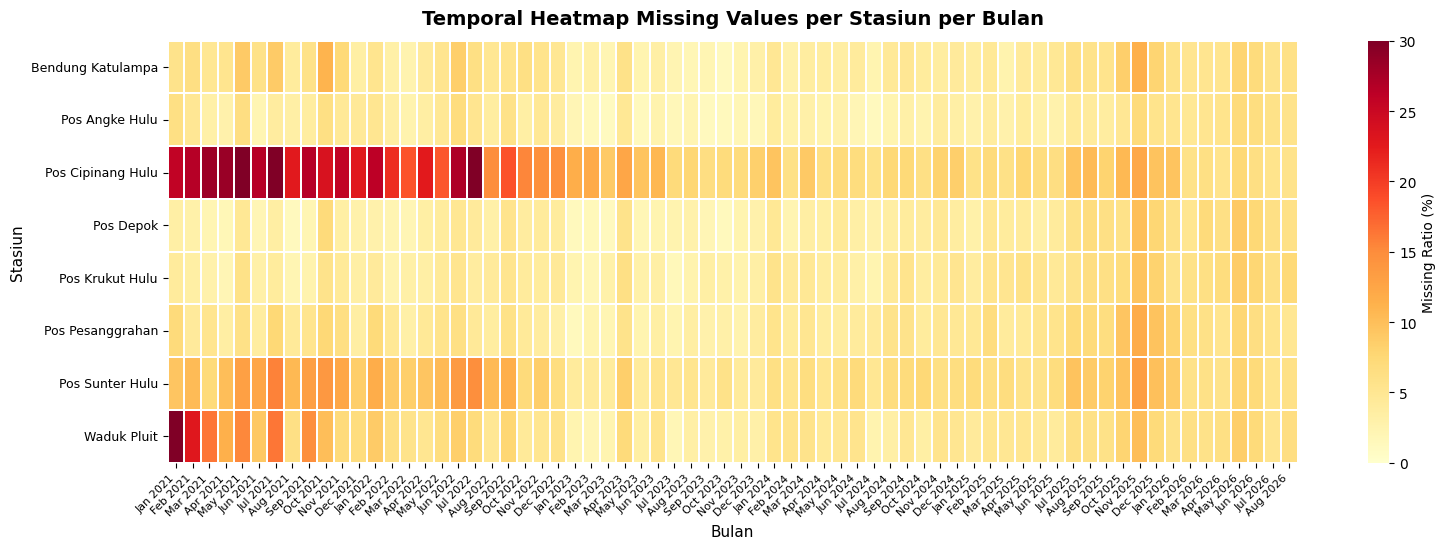


Interpretasi heatmap:
- Warna putih/kuning: data lengkap atau hampir lengkap
- Warna oranye/merah: periode dengan missing data tinggi
- Pola kolom vertikal: gangguan sensor di periode tertentu (bukan random)
- Pola baris horizontal: stasiun tertentu yang konsisten bermasalah


In [ ]:
print("\n" + "=" * 60)
print("TEMPORAL HEATMAP MISSING VALUES")
print("=" * 60)

# Agregasi: apakah ada NaN dalam bulan tersebut per stasiun?
# Kita hitung RASIO missing per bulan per stasiun

# Buat kolom Year-Month untuk groupby
df_wide_copy = df_wide.copy()
df_wide_copy.index = pd.to_datetime(df_wide_copy.index)

# Resample bulanan: hitung rasio NaN per bulan
monthly_missing = (
    df_wide_copy
    .resample('ME')                             # month-end frequency
    .apply(lambda x: x.isna().mean() * 100)   # % missing per bulan
)

# Format index jadi "Jan 2023"
monthly_missing.index = monthly_missing.index.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(16, max(5, len(df_wide.columns) * 0.7)))

sns.heatmap(
    monthly_missing.T,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Missing Ratio (%)'},
    vmin=0,
    vmax=30,
)

ax.set_title('Temporal Heatmap Missing Values per Stasiun per Bulan',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Stasiun', fontsize=11)

# Rotasi label sumbu X supaya readable
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('missing_heatmap_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretasi heatmap:")
print("- Warna putih/kuning: data lengkap atau hampir lengkap")
print("- Warna oranye/merah: periode dengan missing data tinggi")
print("- Pola kolom vertikal: gangguan sensor di periode tertentu (bukan random)")
print("- Pola baris horizontal: stasiun tertentu yang konsisten bermasalah")

# Basic EDA

In [ ]:
import matplotlib.pyplot as plt

## Statistic Descriptive

In [ ]:
print("\n=== STATISTIK DESKRIPTIF ===")

desc = df.describe()
display(desc)

print("\n=== SKEWNESS ===")
display(df.skew().to_frame(name='skewness'))

print("\n=== KURTOSIS ===")
display(df.kurtosis().to_frame(name='kurtosis'))


=== STATISTIK DESKRIPTIF ===


station_name,Bendung Katulampa,Pos Angke Hulu,Pos Cipinang Hulu,Pos Depok,Pos Krukut Hulu,Pos Pesanggrahan,Pos Sunter Hulu,Waduk Pluit
count,46715.000000,47292.000000,42581.000000,47173.000000,46918.000000,46651.000000,45214.000000,45838.000000
mean,19.288851,70.527372,85.107571,96.336744,43.576751,80.281859,100.347931,-180.356800
std,13.726065,50.506977,17.906655,25.058631,24.377613,26.051624,29.568089,20.476729
min,-170.000000,0.000000,-240.000000,-190.000000,-190.000000,-190.000000,0.000000,-1904.000000
25%,10.000000,40.000000,75.000000,80.000000,30.000000,65.000000,90.000000,-190.000000
50%,20.000000,50.000000,80.000000,95.000000,40.000000,70.000000,90.000000,-185.000000
75%,20.000000,80.000000,90.000000,105.000000,50.000000,90.000000,110.000000,-175.000000
max,300.000000,640.000000,230.000000,1000.000000,660.000000,600.000000,880.000000,200.000000



=== SKEWNESS ===


,skewness
station_name,
Bendung Katulampa,2.943050
Pos Angke Hulu,2.526898
Pos Cipinang Hulu,0.715704
Pos Depok,3.058605
Pos Krukut Hulu,2.420567
Pos Pesanggrahan,2.642550
Pos Sunter Hulu,2.402028
Waduk Pluit,-31.048437



=== KURTOSIS ===


,kurtosis
station_name,
Bendung Katulampa,20.344596
Pos Angke Hulu,7.763462
Pos Cipinang Hulu,19.800603
Pos Depok,55.477535
Pos Krukut Hulu,18.694901
Pos Pesanggrahan,13.160627
Pos Sunter Hulu,17.293597
Waduk Pluit,2868.944444


## Water Level Distribution


=== DISTRIBUSI WATER LEVEL ===


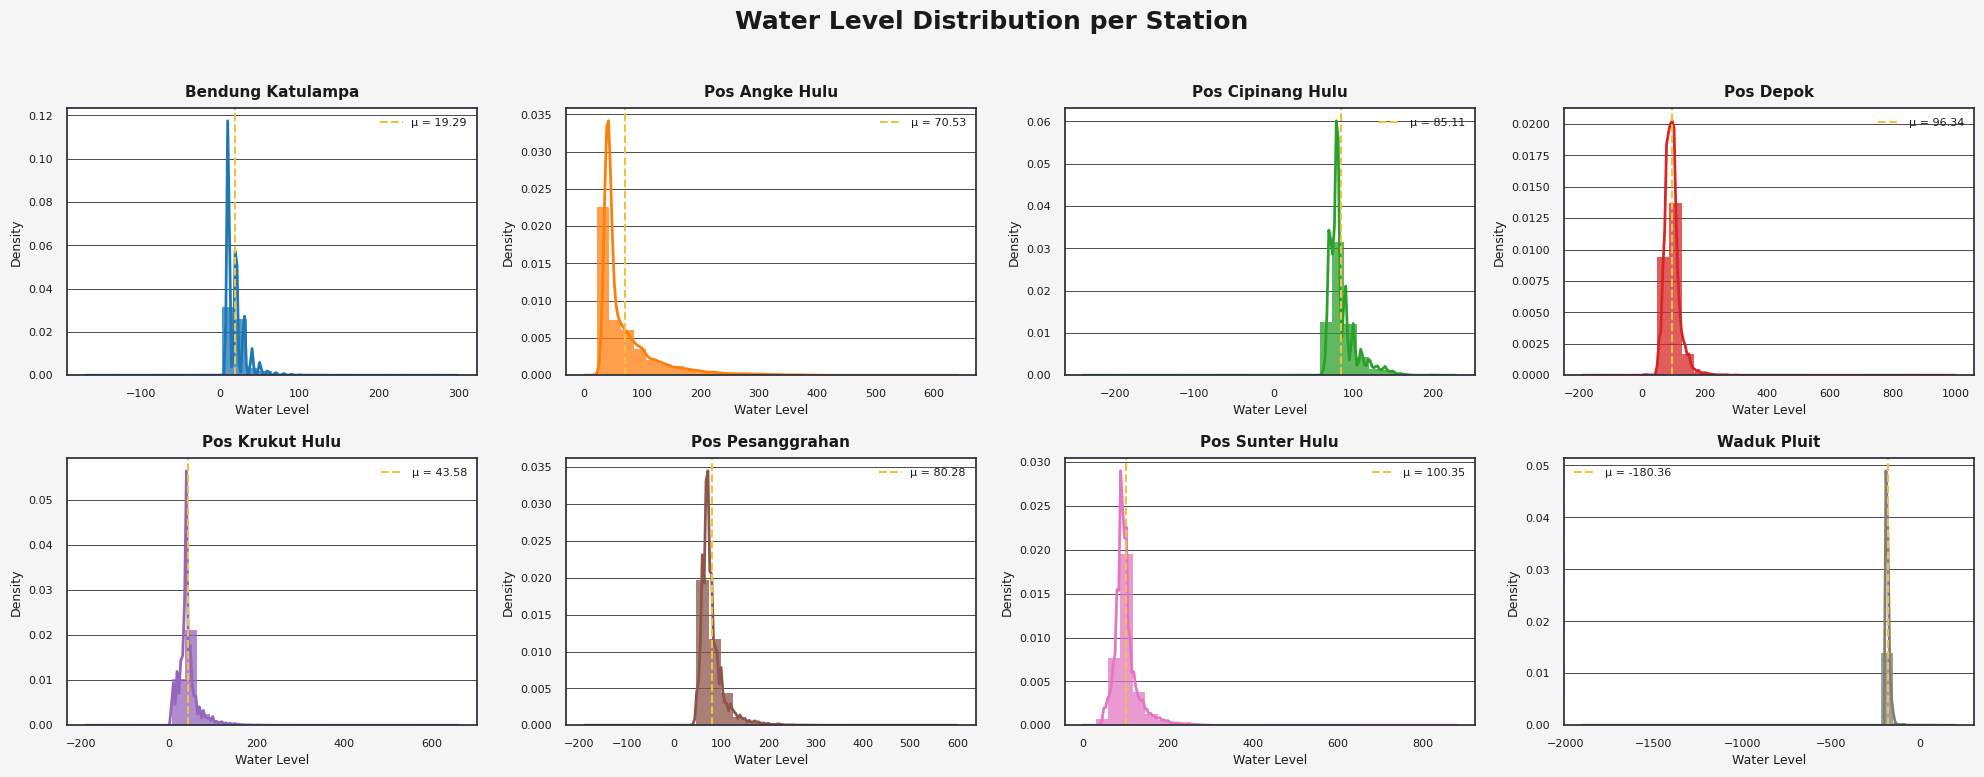

In [ ]:
print("\n=== DISTRIBUSI WATER LEVEL ===")

# ── Config ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")
PALETTE   = sns.color_palette("tab10", n_colors=len(df.columns))
BG_OUTER  = "#f5f5f5"
BG_INNER  = "#ffffff"
TEXT_COL  = "#1a1a1a"
GRID_COL  = "#2a2d3a"

# ── Layout ────────────────────────────────────────────────────────────────────
n_cols  = 4
n_rows  = int(np.ceil(len(df.columns) / n_cols))
fig     = plt.figure(figsize=(n_cols * 5, n_rows * 3.8), facecolor=BG_OUTER)
fig.suptitle(
    "Water Level Distribution per Station",
    fontsize=18, fontweight="bold", color=TEXT_COL,
    y=1.02
)

axes = fig.subplots(n_rows, n_cols)
axes = np.array(axes).flatten()          # always iterable

for idx, (col, color) in enumerate(zip(df.columns, PALETTE)):
    ax  = axes[idx]
    data = df[col].dropna()

    # Histogram + KDE
    sns.histplot(
        data, ax=ax, color=color, bins=30,
        kde=True, stat="density",
        line_kws={"lw": 2},
        edgecolor="none", alpha=0.75,
    )

    # Mean line
    mean_val = data.mean()
    ax.axvline(mean_val, color="#f0c040", lw=1.5, ls="--", label=f"μ = {mean_val:.2f}")

    # Styling
    ax.set_facecolor(BG_INNER)
    ax.set_title(col, fontsize=11, fontweight="semibold", color=TEXT_COL, pad=8)
    ax.set_xlabel("Water Level", fontsize=9, color=TEXT_COL)
    ax.set_ylabel("Density",     fontsize=9, color=TEXT_COL)
    ax.tick_params(colors=TEXT_COL, labelsize=8)
    ax.legend(fontsize=8, frameon=False, labelcolor=TEXT_COL)

    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.yaxis.grid(True, color=GRID_COL, lw=0.6)
    ax.xaxis.grid(False)

# Hide unused subplot slots
for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("water_level_dist.png", dpi=300, bbox_inches="tight",
            facecolor=BG_OUTER)
plt.show()

## Boxplot Water Level per Station

/tmp/ipykernel_711/4142790313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


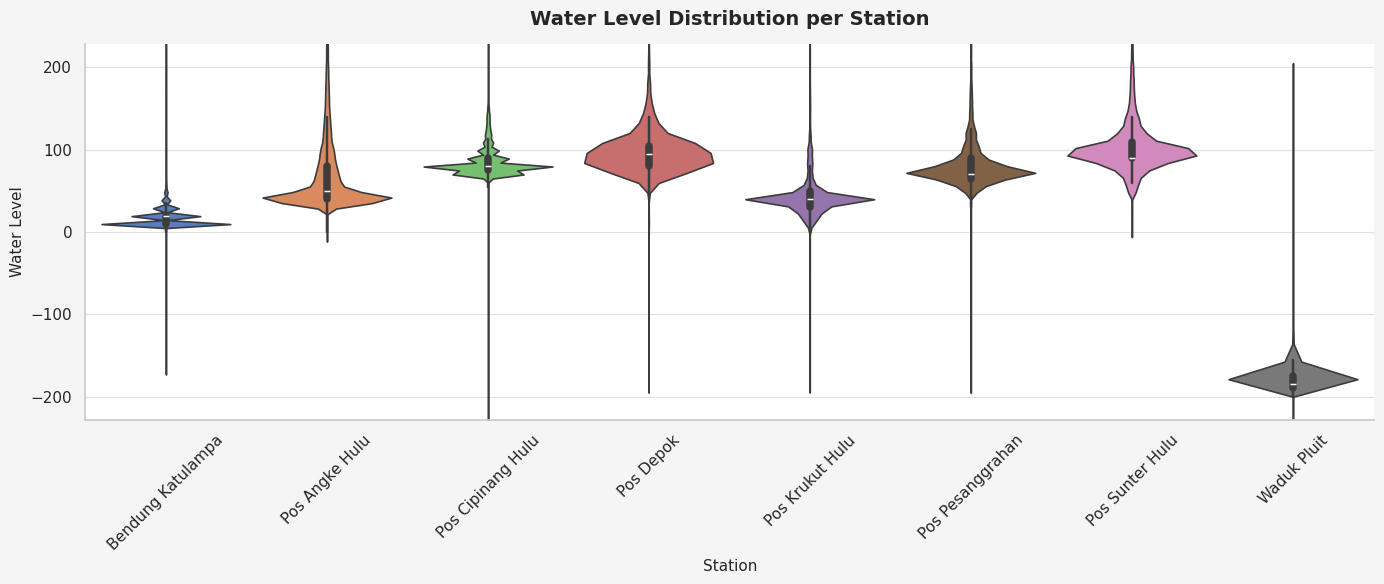

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor="#f5f5f5")

df_melt = df.melt(var_name="Station", value_name="Water Level")

sns.violinplot(
    data=df_melt,
    x="Station", y="Water Level",
    palette="muted",
    inner="box",      # tetap nampilin IQR & median di dalam
    linewidth=1.2,
    ax=ax,
)

# ✅ Clip y-axis — buang outlier ekstrem dari view tanpa hapus data
q_low  = df_melt["Water Level"].quantile(0.01)
q_high = df_melt["Water Level"].quantile(0.99)
ax.set_ylim(q_low * 1.2, q_high * 1.2)

# Styling
ax.set_facecolor("#ffffff")
ax.set_title("Water Level Distribution per Station", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Station", fontsize=11)
ax.set_ylabel("Water Level", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.grid(True, color="#e0e0e0", lw=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("violinplot.png", dpi=300, bbox_inches="tight",
            facecolor=BG_OUTER)
plt.show()

## Time Series per Station


=== TIME SERIES PER STATION ===


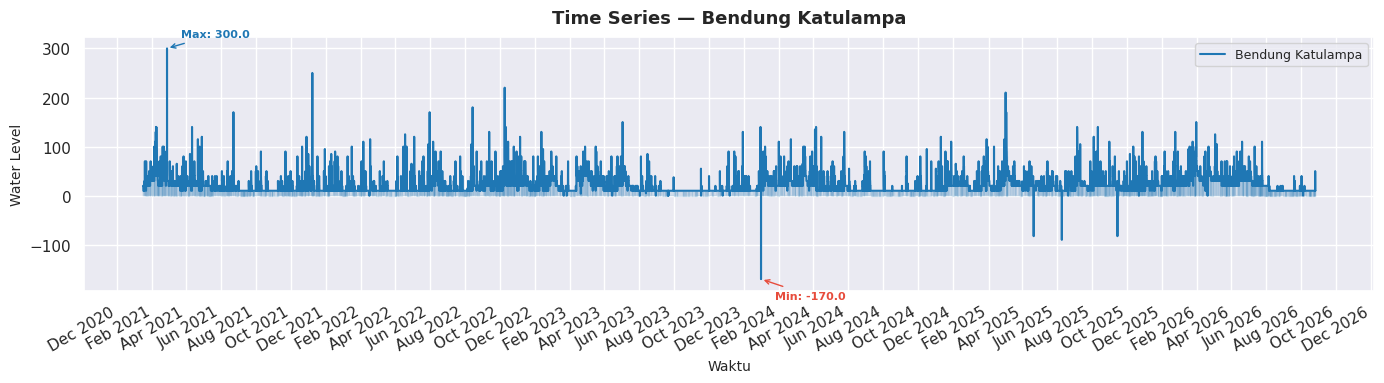

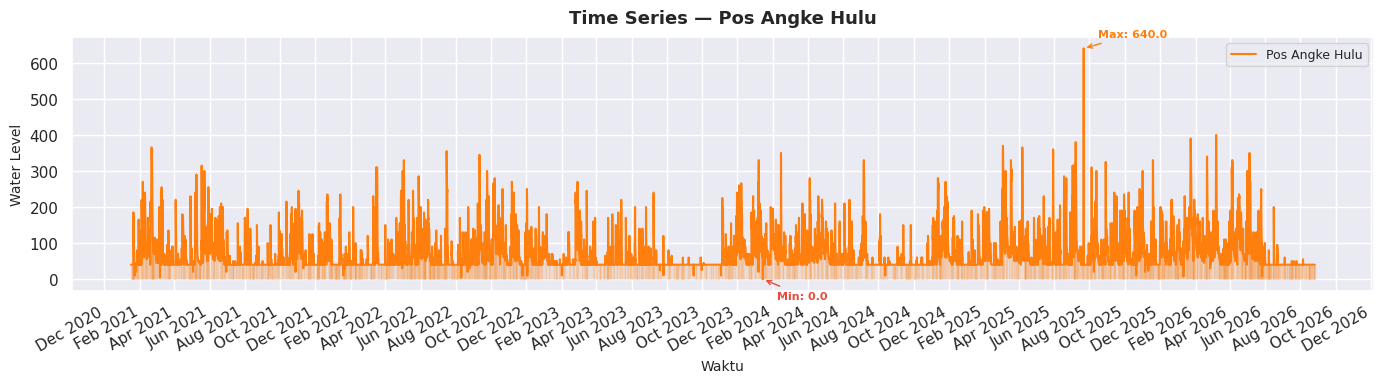

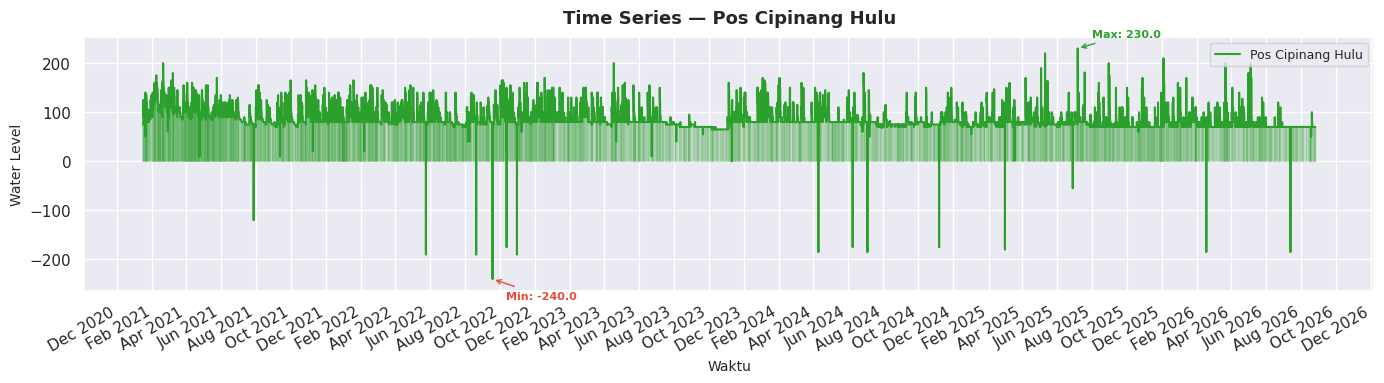

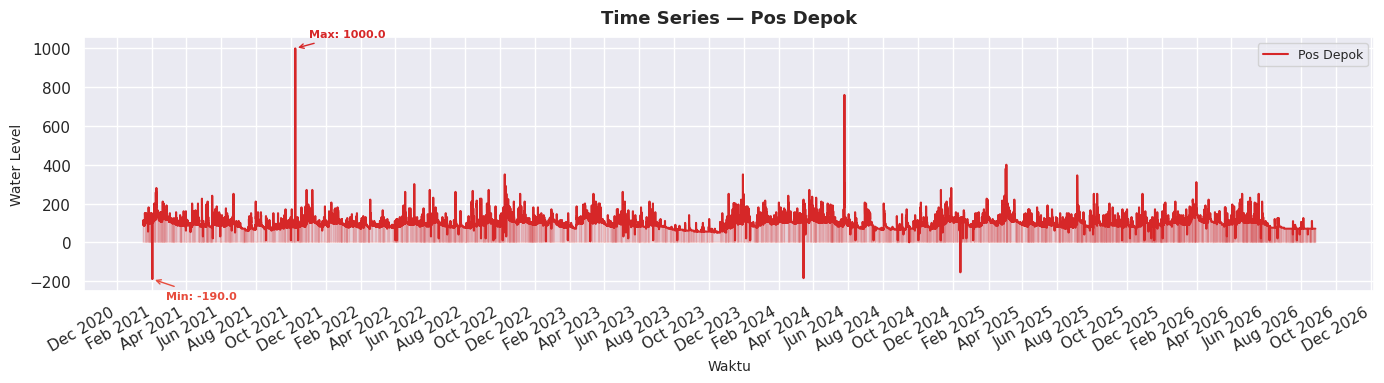

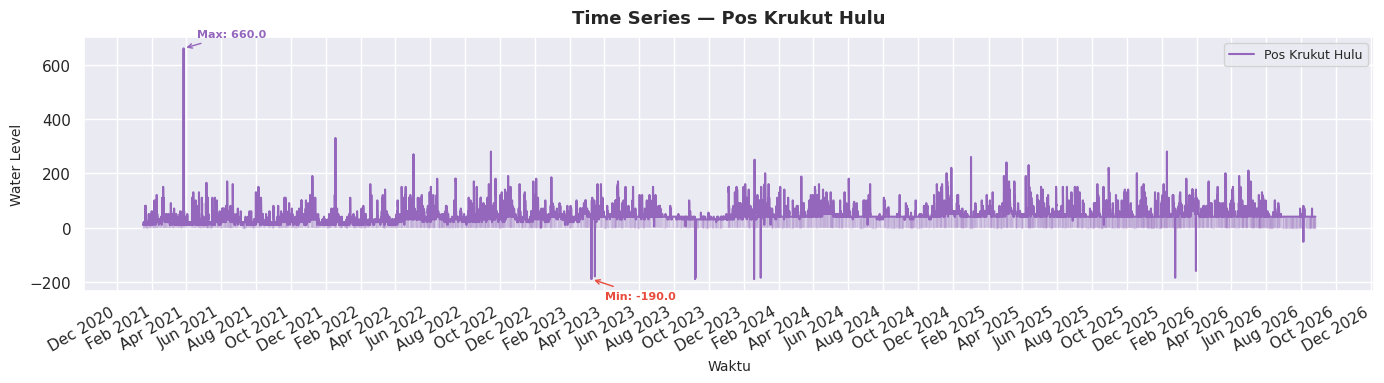

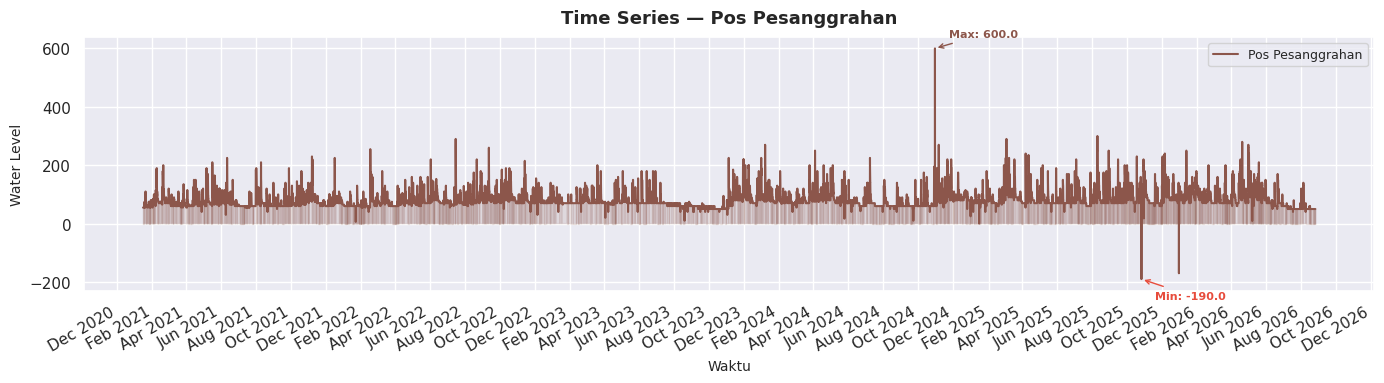

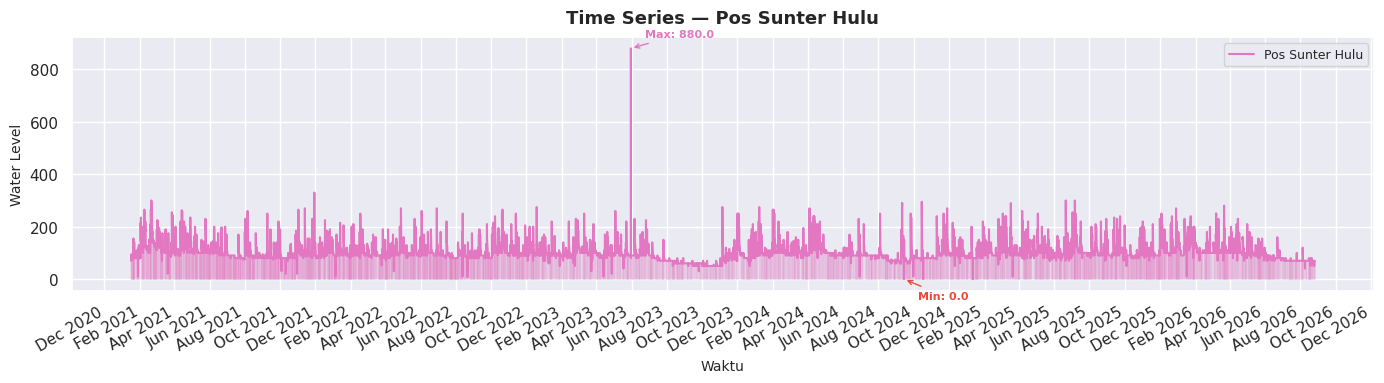

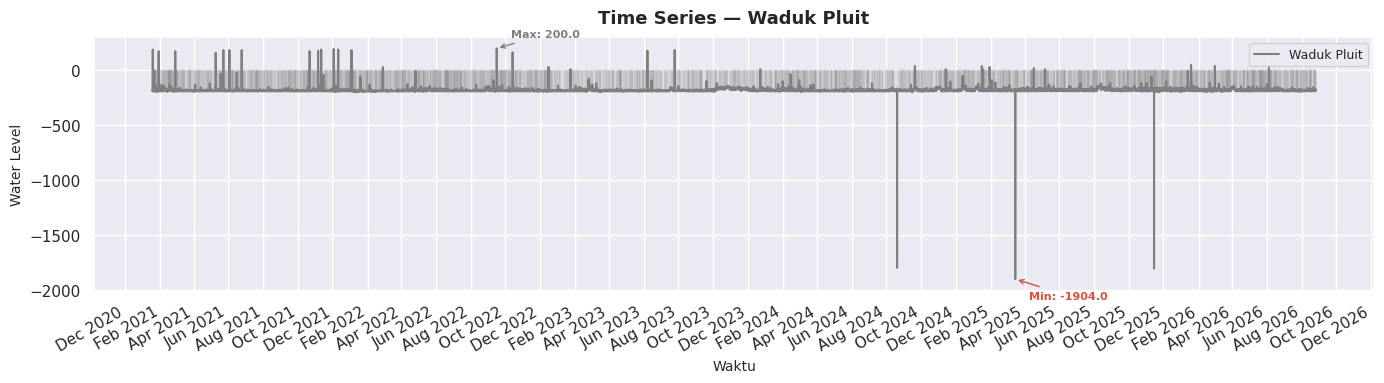

In [ ]:
print("\n=== TIME SERIES PER STATION ===")

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style="darkgrid")
palette = sns.color_palette("tab10", len(df.columns))

for col, color in zip(df.columns, palette):
    fig, ax = plt.subplots(figsize=(14, 4))

    # Area + line
    ax.fill_between(df.index, df[col], alpha=0.12, color=color)
    sns.lineplot(
        x=df.index, y=df[col],
        ax=ax, color=color,
        linewidth=1.5, label=col
    )

    # Annotasi min & max
    series = df[col].dropna()
    if not series.empty:
        idx_max = series.idxmax()
        idx_min = series.idxmin()

        ax.annotate(
            f"Max: {series.max():.1f}",
            xy=(idx_max, series.max()),
            xytext=(10, 8), textcoords='offset points',
            fontsize=8, fontweight='bold', color=color,
            arrowprops=dict(arrowstyle='->', color=color, lw=1)
        )
        ax.annotate(
            f"Min: {series.min():.1f}",
            xy=(idx_min, series.min()),
            xytext=(10, -14), textcoords='offset points',
            fontsize=8, fontweight='bold', color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1)
        )

    # Formatting
    ax.set_title(f"Time Series — {col}", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu", fontsize=10)
    ax.set_ylabel("Water Level", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=30, ha='right')
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

## Hourly Pattern


=== POLA TEMPORAL ===


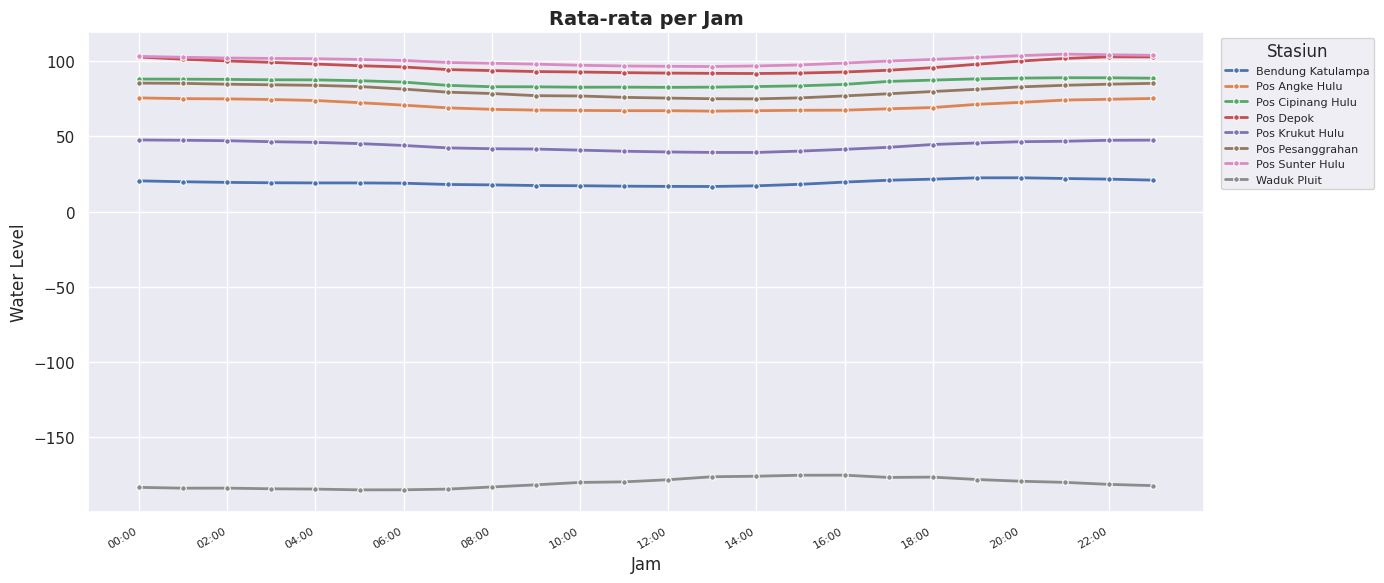

Saved: temporal_plots/hourly_pattern.png


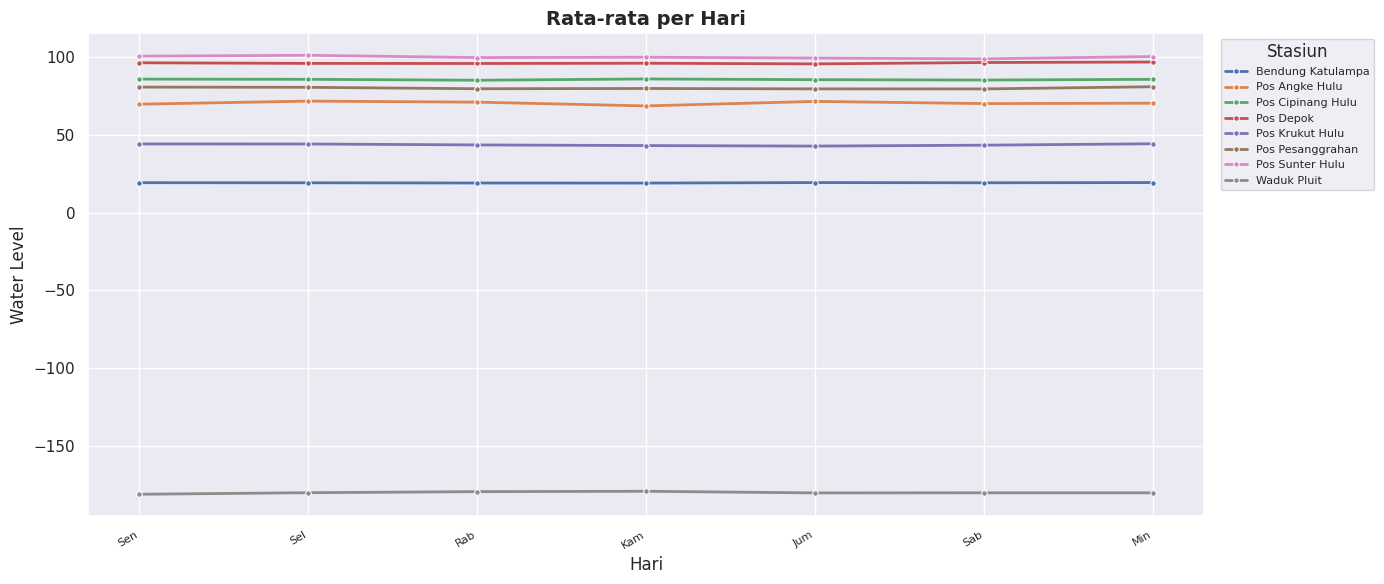

Saved: temporal_plots/daily_pattern.png


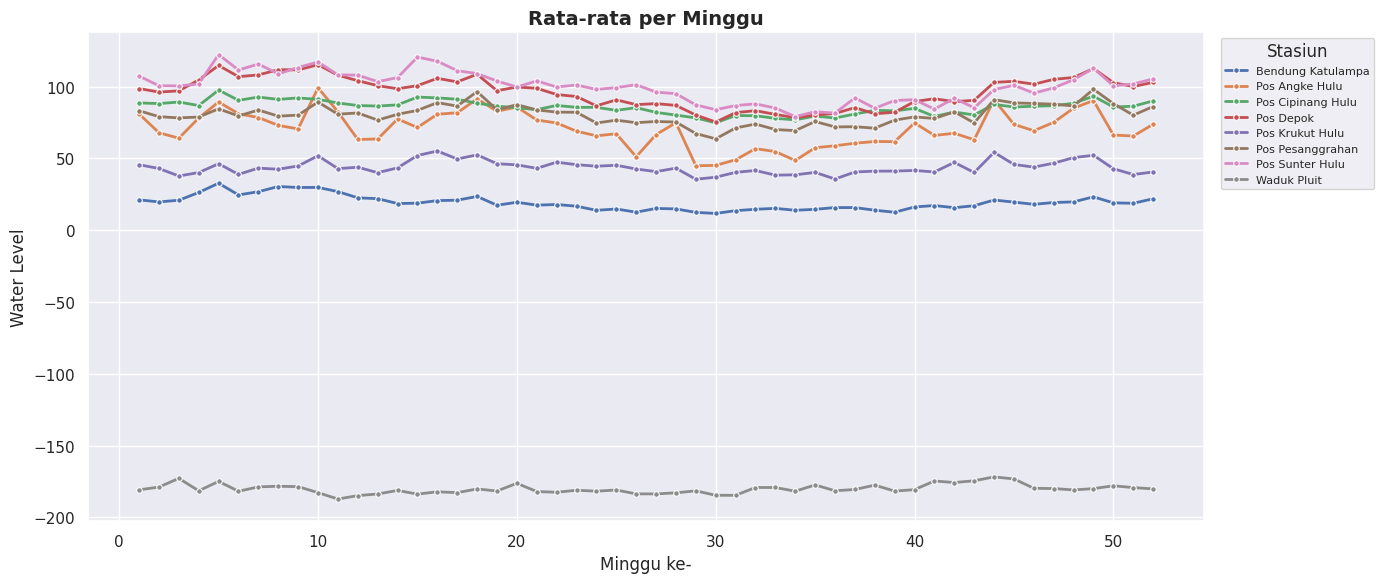

Saved: temporal_plots/weekly_pattern.png


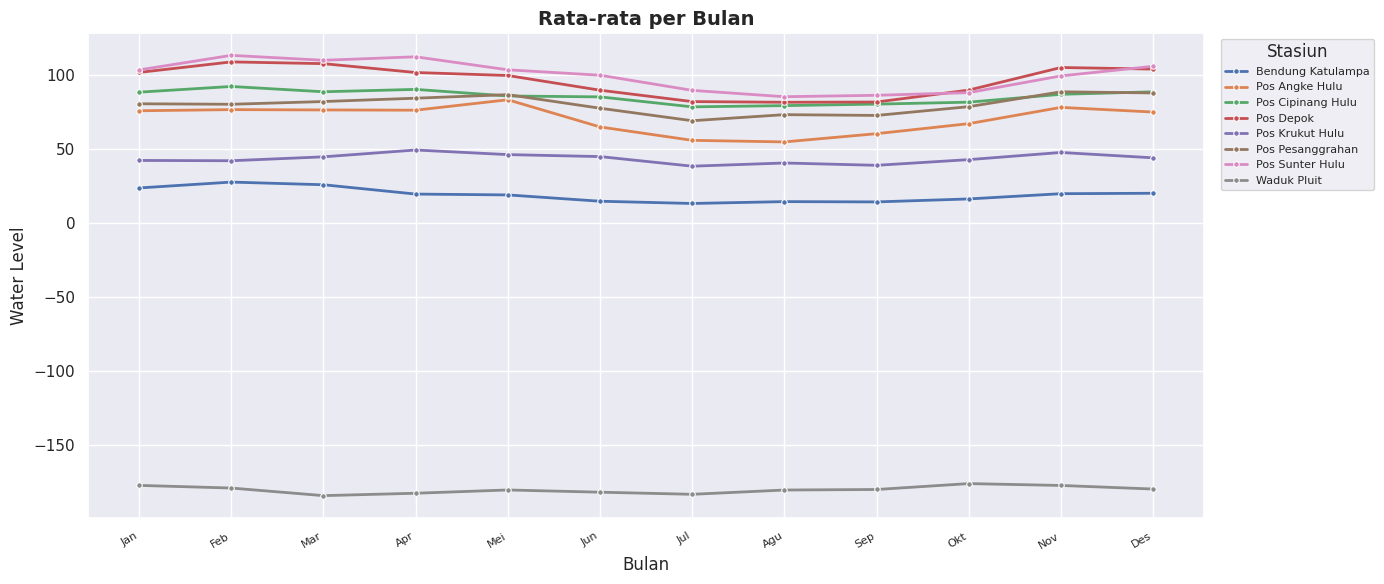

Saved: temporal_plots/monthly_pattern.png


In [ ]:
print("\n=== POLA TEMPORAL ===")

import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

# ====================================================
# OUTPUT DIRECTORY
# ====================================================

save_dir = "temporal_plots"
os.makedirs(save_dir, exist_ok=True)

month_labels = [
    'Jan','Feb','Mar','Apr','Mei','Jun',
    'Jul','Agu','Sep','Okt','Nov','Des'
]

day_labels = [
    'Sen','Sel','Rab',
    'Kam','Jum','Sab','Min'
]

# ====================================================
# HELPER FUNCTION
# ====================================================

def create_temporal_plot(
    data,
    x_col,
    title,
    xlabel,
    filename,
    x_ticks=None,
    x_ticklabels=None
):

    plt.figure(figsize=(14, 6))

    melted = data.melt(
        id_vars=x_col,
        var_name='Stasiun',
        value_name='Water Level'
    )

    sns.lineplot(
        data=melted,
        x=x_col,
        y='Water Level',
        hue='Stasiun',
        linewidth=2,
        marker='o',
        markersize=4
    )

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel("Water Level")

    if x_ticks is not None:
        plt.xticks(
            ticks=x_ticks,
            labels=x_ticklabels,
            rotation=30,
            ha='right',
            fontsize=8
        )

    plt.legend(
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        fontsize=8,
        title='Stasiun'
    )

    plt.tight_layout()

    save_path = os.path.join(save_dir, filename)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print(f"Saved: {save_path}")

# ====================================================
# HOURLY PATTERN
# ====================================================

hourly = (
    df_filled
    .groupby(df_filled.index.hour)
    .mean()
    .reset_index()
)

hourly.columns = ['Hour'] + list(hourly.columns[1:])

create_temporal_plot(
    data=hourly,
    x_col='Hour',
    title='Rata-rata per Jam',
    xlabel='Jam',
    filename='hourly_pattern.png',
    x_ticks=range(0, 24, 2),
    x_ticklabels=[f"{h:02d}:00" for h in range(0, 24, 2)]
)

# ====================================================
# DAILY PATTERN
# ====================================================

daily = (
    df_filled
    .groupby(df_filled.index.dayofweek)
    .mean()
    .reset_index()
)

daily.columns = ['Day'] + list(daily.columns[1:])

create_temporal_plot(
    data=daily,
    x_col='Day',
    title='Rata-rata per Hari',
    xlabel='Hari',
    filename='daily_pattern.png',
    x_ticks=range(7),
    x_ticklabels=day_labels
)

# ====================================================
# WEEKLY PATTERN
# ====================================================

weekly = (
    df_filled
    .groupby(df_filled.index.isocalendar().week)
    .mean()
    .reset_index()
)

weekly.columns = ['Week'] + list(weekly.columns[1:])

create_temporal_plot(
    data=weekly,
    x_col='Week',
    title='Rata-rata per Minggu',
    xlabel='Minggu ke-',
    filename='weekly_pattern.png'
)

# ====================================================
# MONTHLY PATTERN
# ====================================================

monthly = (
    df_filled
    .groupby(df_filled.index.month)
    .mean()
    .reset_index()
)

monthly.columns = ['Month'] + list(monthly.columns[1:])

create_temporal_plot(
    data=monthly,
    x_col='Month',
    title='Rata-rata per Bulan',
    xlabel='Bulan',
    filename='monthly_pattern.png',
    x_ticks=range(1, 13),
    x_ticklabels=month_labels
)

In [ ]:
monthly

,Month,Bendung Katulampa,Pos Angke Hulu,Pos Cipinang Hulu,Pos Depok,Pos Krukut Hulu,Pos Pesanggrahan,Pos Sunter Hulu,Waduk Pluit
0,1,23.917398,76.129508,88.704434,102.069932,42.527778,80.860746,103.753046,-177.301151
1,2,27.881903,76.904956,92.569845,109.184673,42.323718,80.521820,113.621322,-179.096532
2,3,26.084192,76.687388,88.978345,108.005712,44.964456,82.373432,110.289091,-184.234468
3,4,19.771123,76.524074,90.595807,102.010880,49.585995,84.631944,112.641725,-182.610222
4,5,19.201240,83.574709,86.129770,99.988687,46.466174,87.039763,103.839046,-180.394881
5,6,14.932002,65.191319,85.529234,90.038194,45.137500,77.848553,100.184606,-181.904630
6,7,13.417899,56.128248,78.768512,82.336358,38.637433,69.396617,89.926075,-183.329606
7,8,14.670332,55.053009,79.611661,81.879630,40.803588,73.498148,85.636690,-180.436960
8,9,14.469514,60.632639,80.630525,82.046181,39.227778,72.973472,86.599583,-180.076817
9,10,16.482719,67.409405,81.944765,90.126393,43.070330,78.903976,88.388490,-176.086607


## Extreme Value Check

In [ ]:
print("\n=== EXTREME VALUE CHECK ===")

max_values = df.max().sort_values(ascending=False)
min_values = df.min().sort_values()

display(max_values.to_frame(name='max_water_level'))
display(min_values.to_frame(name='min_water_level'))


=== EXTREME VALUE CHECK ===


,max_water_level
station_name,
Pos Depok,1000.0
Pos Sunter Hulu,880.0
Pos Krukut Hulu,660.0
Pos Angke Hulu,640.0
Pos Pesanggrahan,600.0
Bendung Katulampa,300.0
Pos Cipinang Hulu,230.0
Waduk Pluit,200.0


,min_water_level
station_name,
Waduk Pluit,-1904.0
Pos Cipinang Hulu,-240.0
Pos Krukut Hulu,-190.0
Pos Depok,-190.0
Pos Pesanggrahan,-190.0
Bendung Katulampa,-170.0
Pos Angke Hulu,0.0
Pos Sunter Hulu,0.0


## Variability (Standard Deviation)

In [ ]:
print("\n=== VARIABILITY (STD DEV) ===")

std_dev = df.std().sort_values(ascending=False)
display(std_dev.to_frame(name='std_dev'))


=== VARIABILITY (STD DEV) ===


,std_dev
station_name,
Pos Angke Hulu,50.506977
Pos Sunter Hulu,29.568089
Pos Pesanggrahan,26.051624
Pos Depok,25.058631
Pos Krukut Hulu,24.377613
Waduk Pluit,20.476729
Pos Cipinang Hulu,17.906655
Bendung Katulampa,13.726065


In [ ]:
REPRESENTATIVE_STATIONS = ['Bendung Katulampa', 'Pos Depok', 'Waduk Pluit']

print("Stasiun representatif yang digunakan untuk analisis dekomposisi:")
for s in REPRESENTATIVE_STATIONS:
    n_valid = df_filled[s].notna().sum()
    print(f"  {s}: {n_valid:,} observasi valid ({n_valid/len(df_filled)*100:.1f}%)")

Stasiun representatif yang digunakan untuk analisis dekomposisi:
  Bendung Katulampa: 49,148 observasi valid (100.0%)
  Pos Depok: 49,148 observasi valid (100.0%)
  Waduk Pluit: 49,106 observasi valid (99.9%)


## **STL Decomposition**

---

STL Decomposition will be done in order to extract seasonal trends in DAS Ciliwung-Jakarta.

> This is done with a representative station, which is Bendung Katulampa station, being the focal point of the DAS being a `stasiun hulu`.


STL DECOMPOSITION — Bendung Katulampa

  Periode: Harian (24 jam)
  Kekuatan Musiman (Fs): 0.165
  Kekuatan Tren    (Ft): 0.606


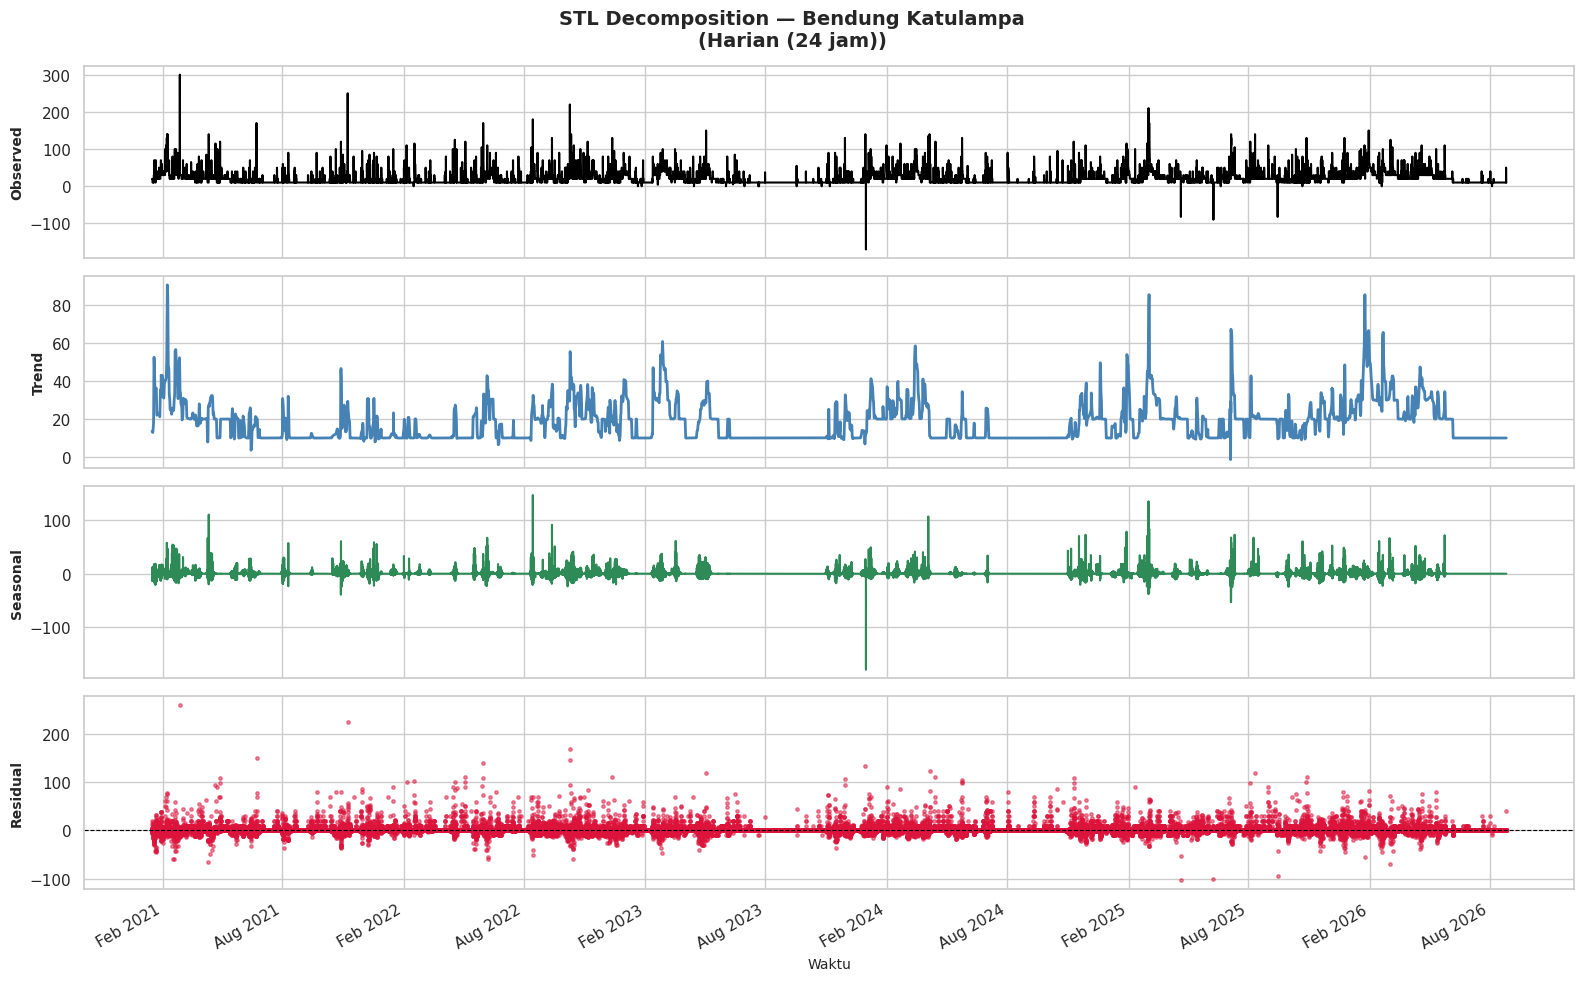

  Saved: stl_Bendung_Katulampa_24h.png

  Periode: Mingguan (168 jam)
  Kekuatan Musiman (Fs): 0.050
  Kekuatan Tren    (Ft): 0.383


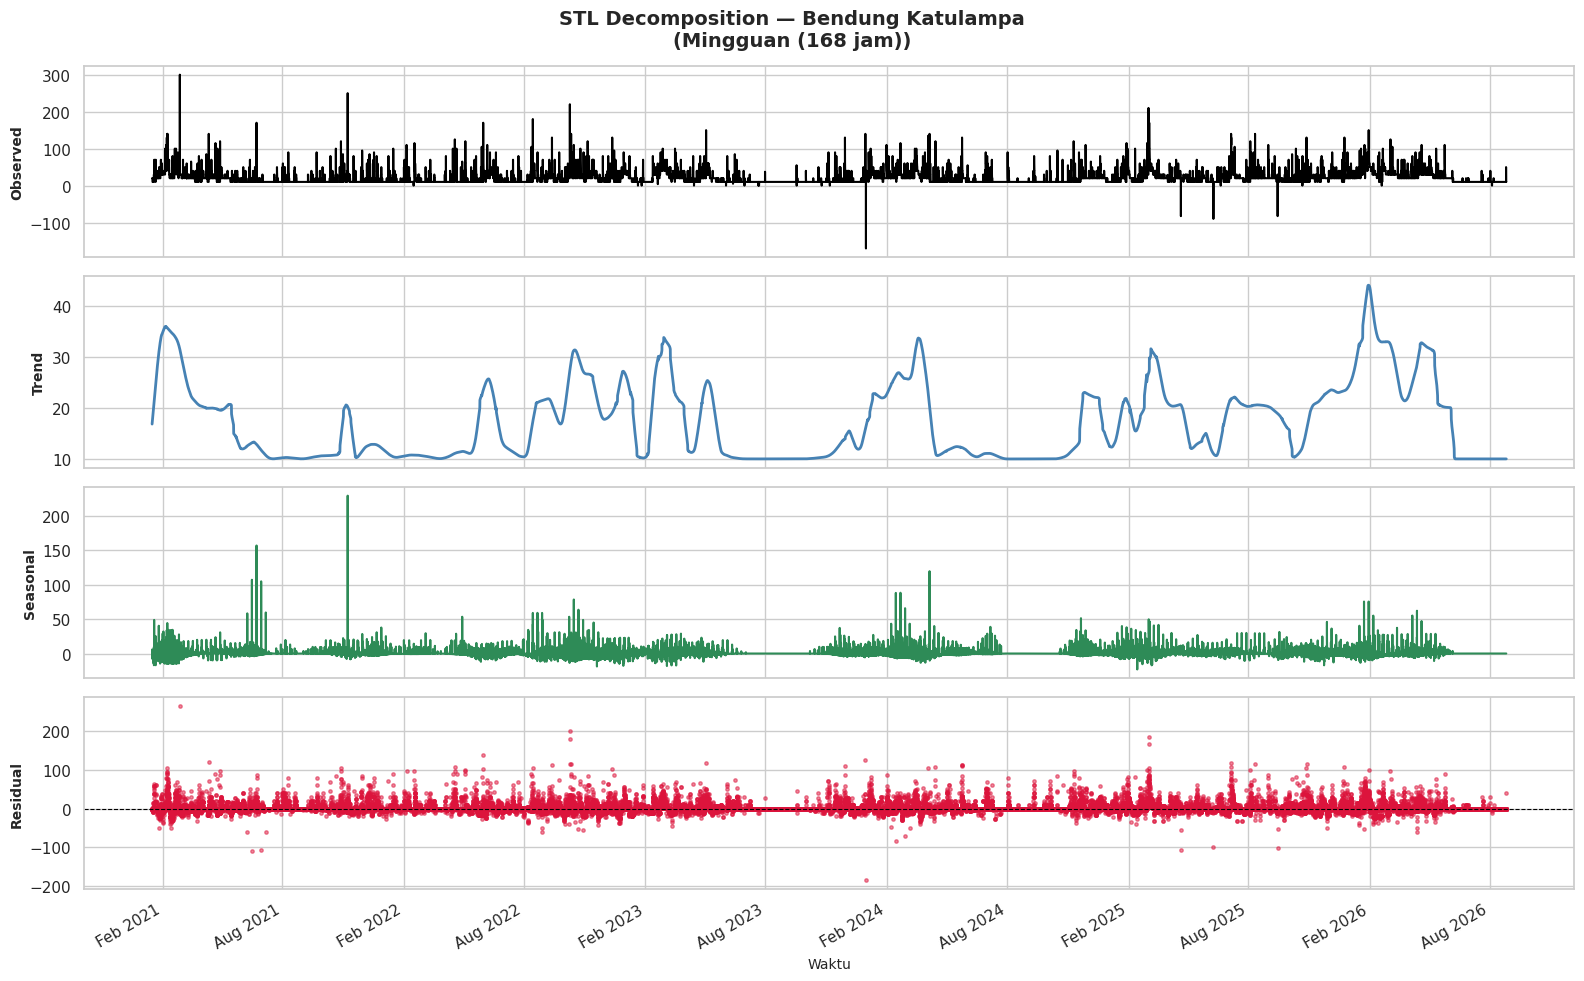

  Saved: stl_Bendung_Katulampa_168h.png

  Periode: Bulanan (720 jam)
  Kekuatan Musiman (Fs): 0.071
  Kekuatan Tren    (Ft): 0.281


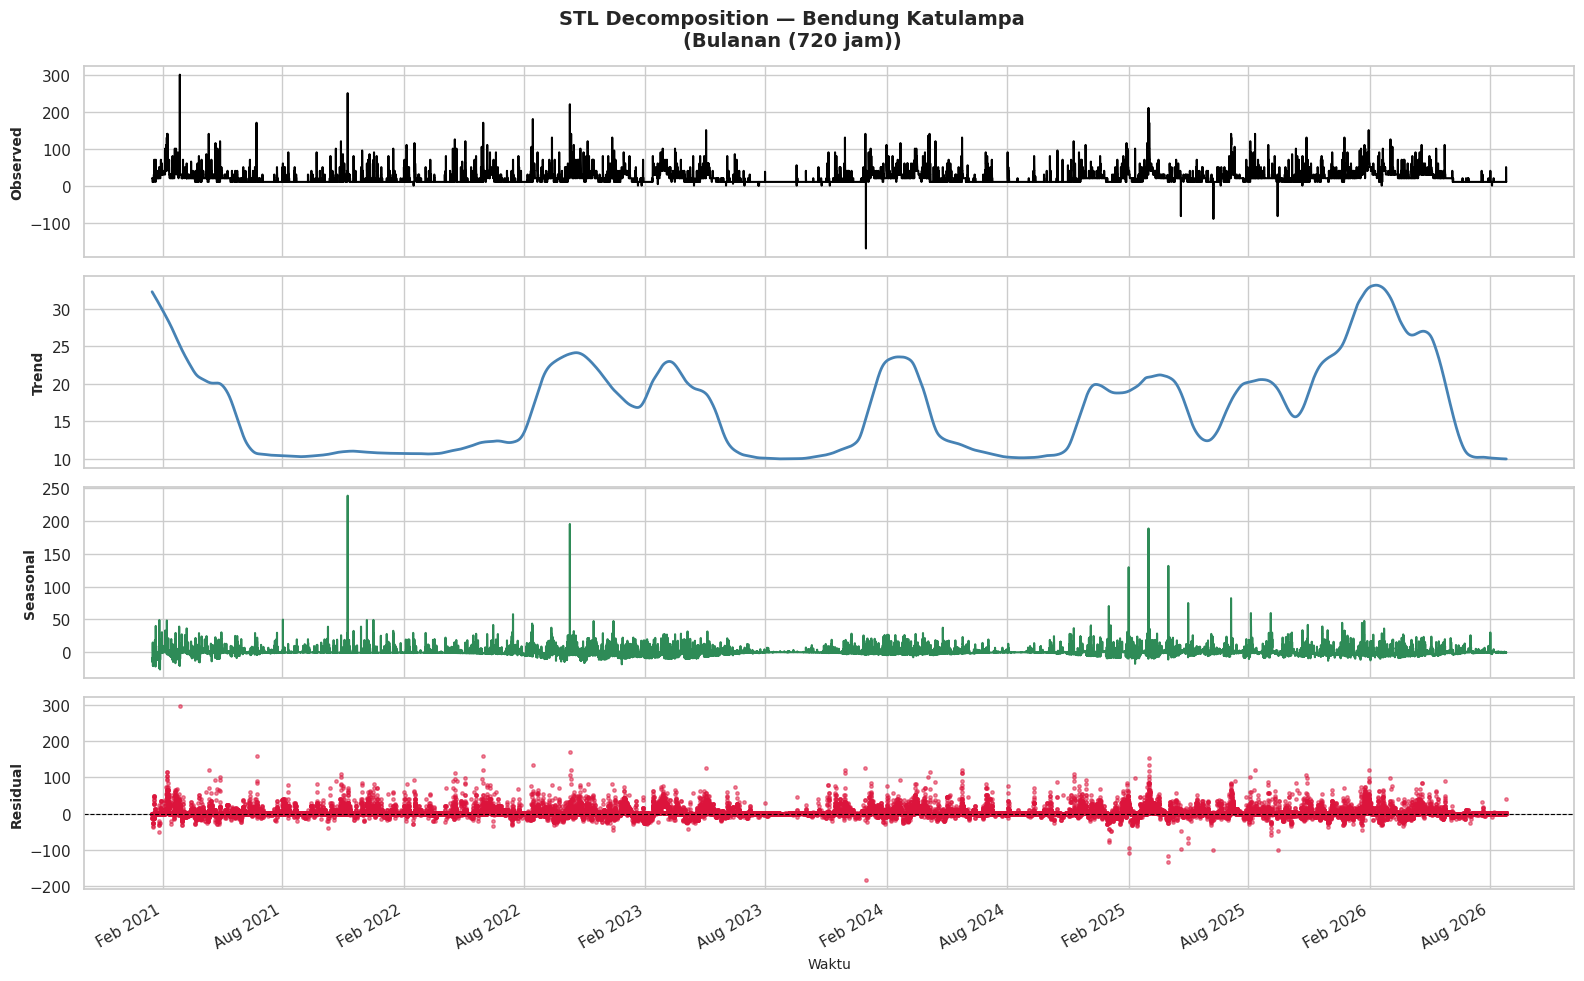

  Saved: stl_Bendung_Katulampa_720h.png

STL DECOMPOSITION — Pos Depok

  Periode: Harian (24 jam)
  Kekuatan Musiman (Fs): 0.079
  Kekuatan Tren    (Ft): 0.589


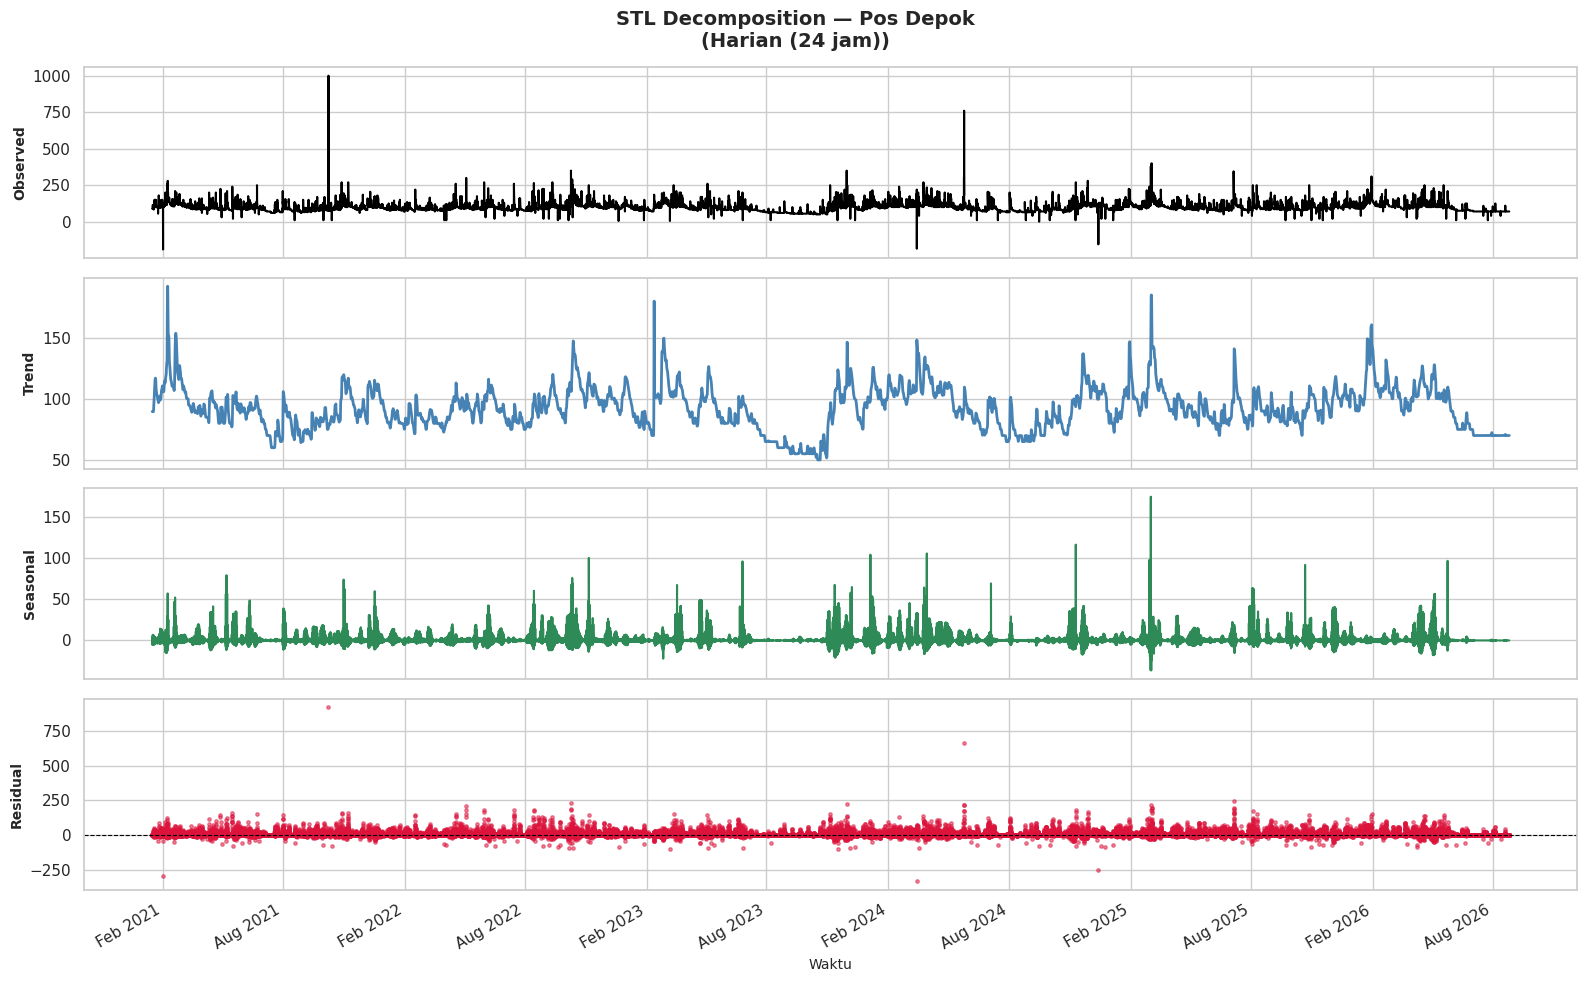

  Saved: stl_Pos_Depok_24h.png

  Periode: Mingguan (168 jam)
  Kekuatan Musiman (Fs): 0.158
  Kekuatan Tren    (Ft): 0.513


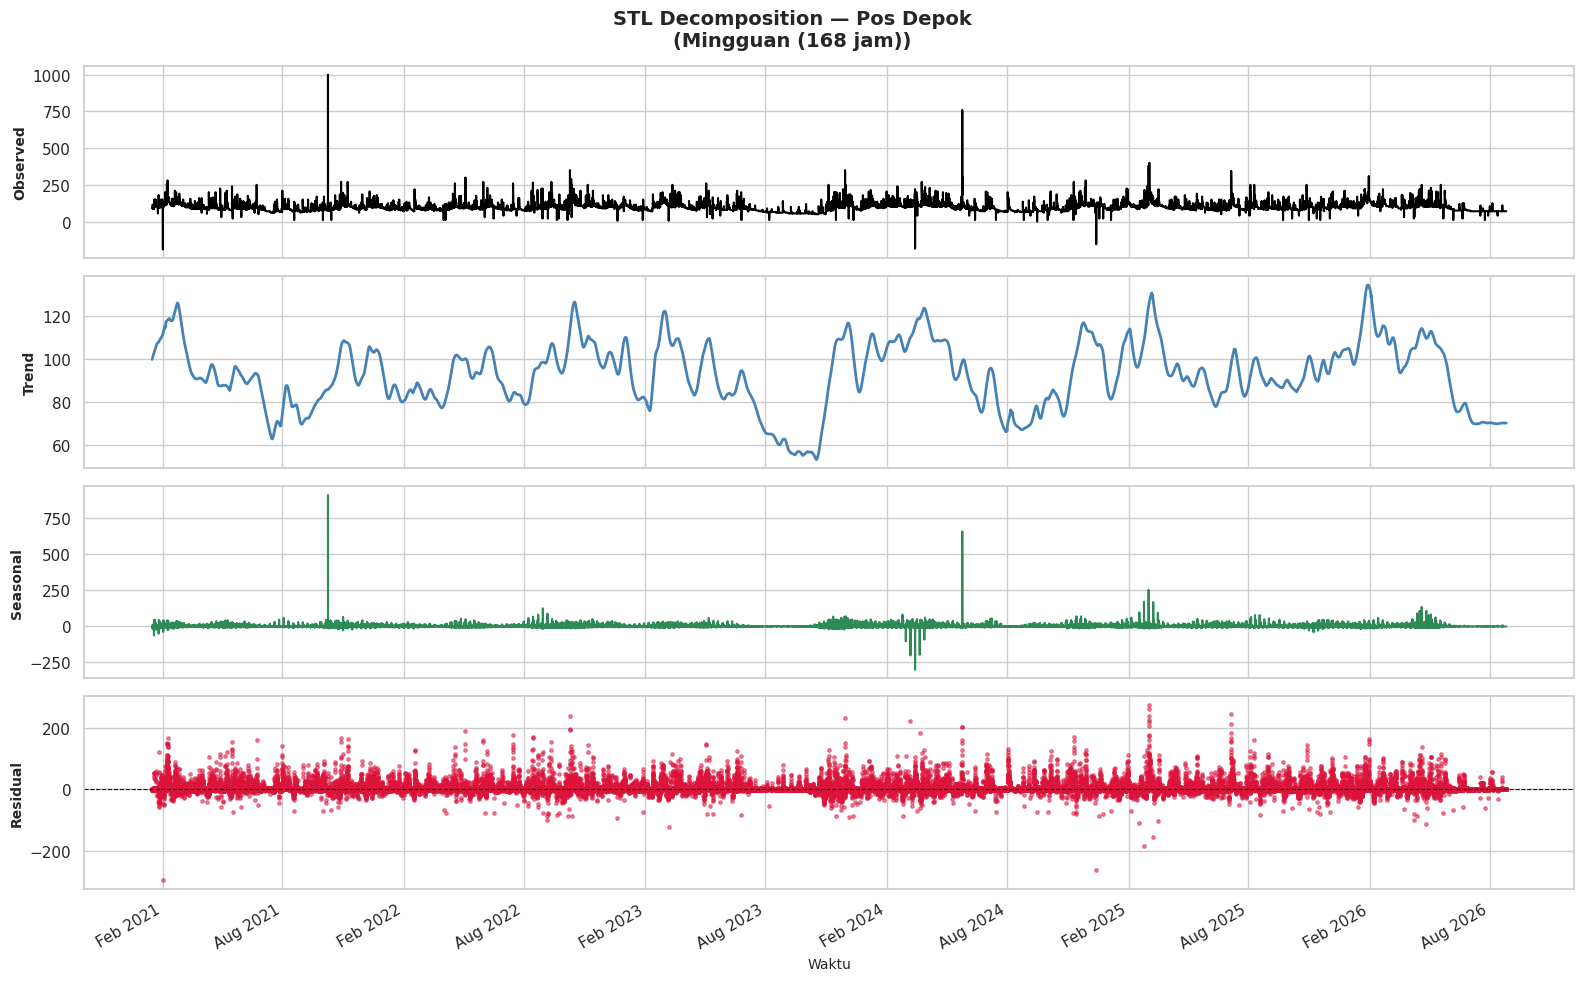

  Saved: stl_Pos_Depok_168h.png

  Periode: Bulanan (720 jam)
  Kekuatan Musiman (Fs): 0.128
  Kekuatan Tren    (Ft): 0.384


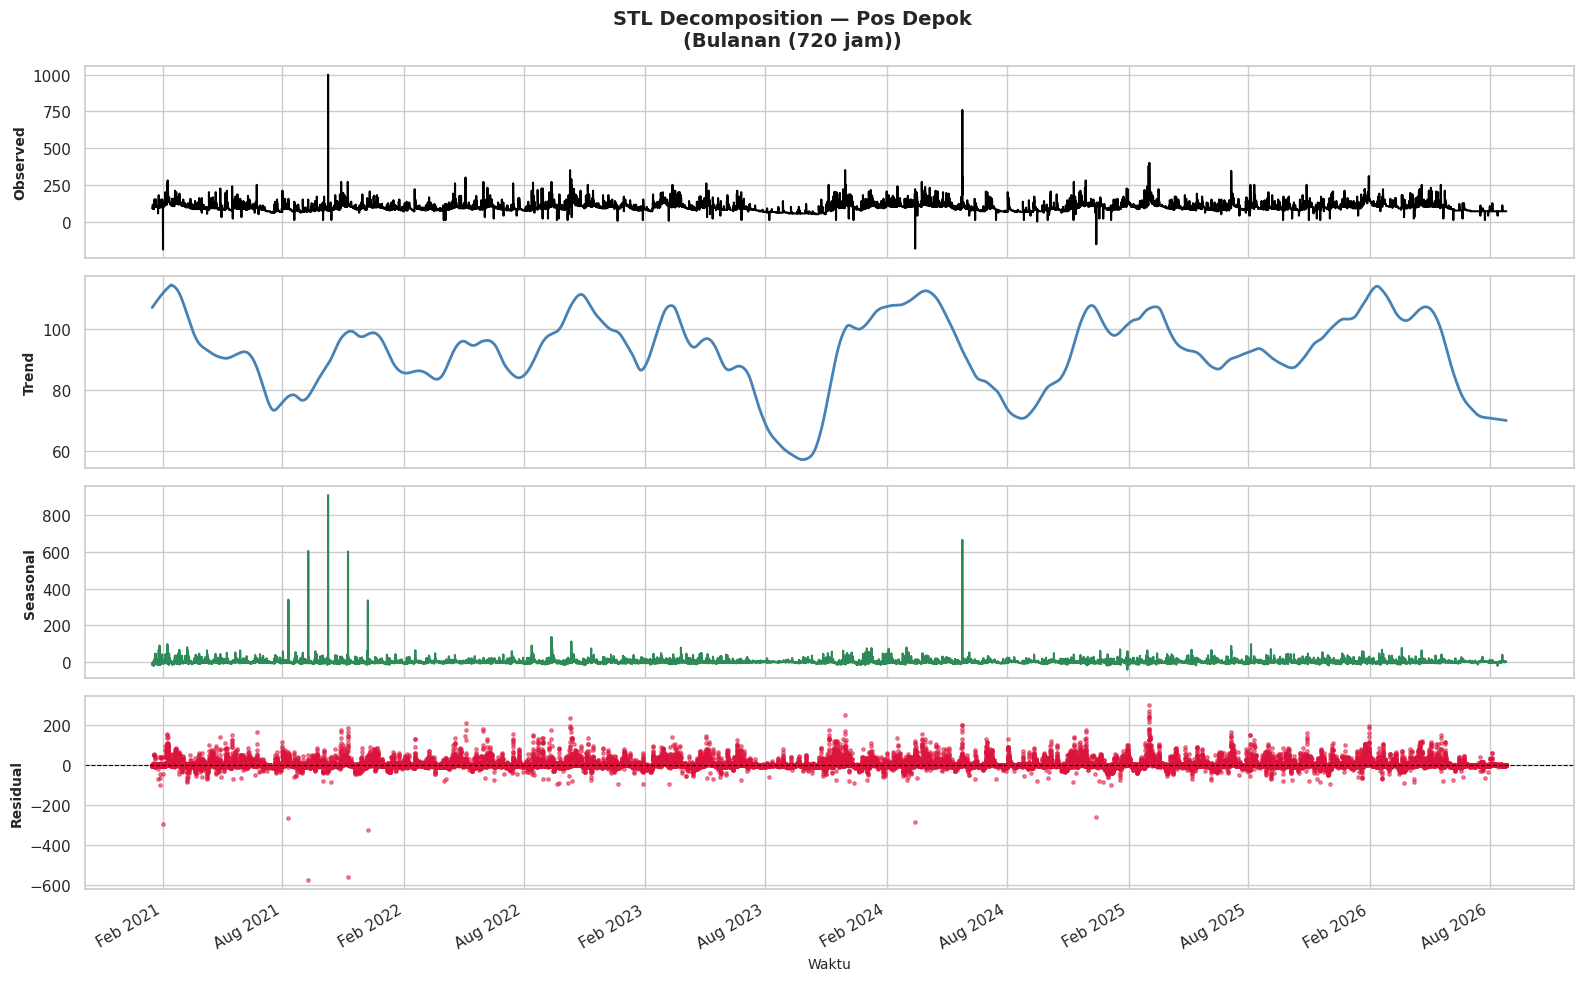

  Saved: stl_Pos_Depok_720h.png

STL DECOMPOSITION — Waduk Pluit

  Periode: Harian (24 jam)
  Kekuatan Musiman (Fs): 0.043
  Kekuatan Tren    (Ft): 0.141


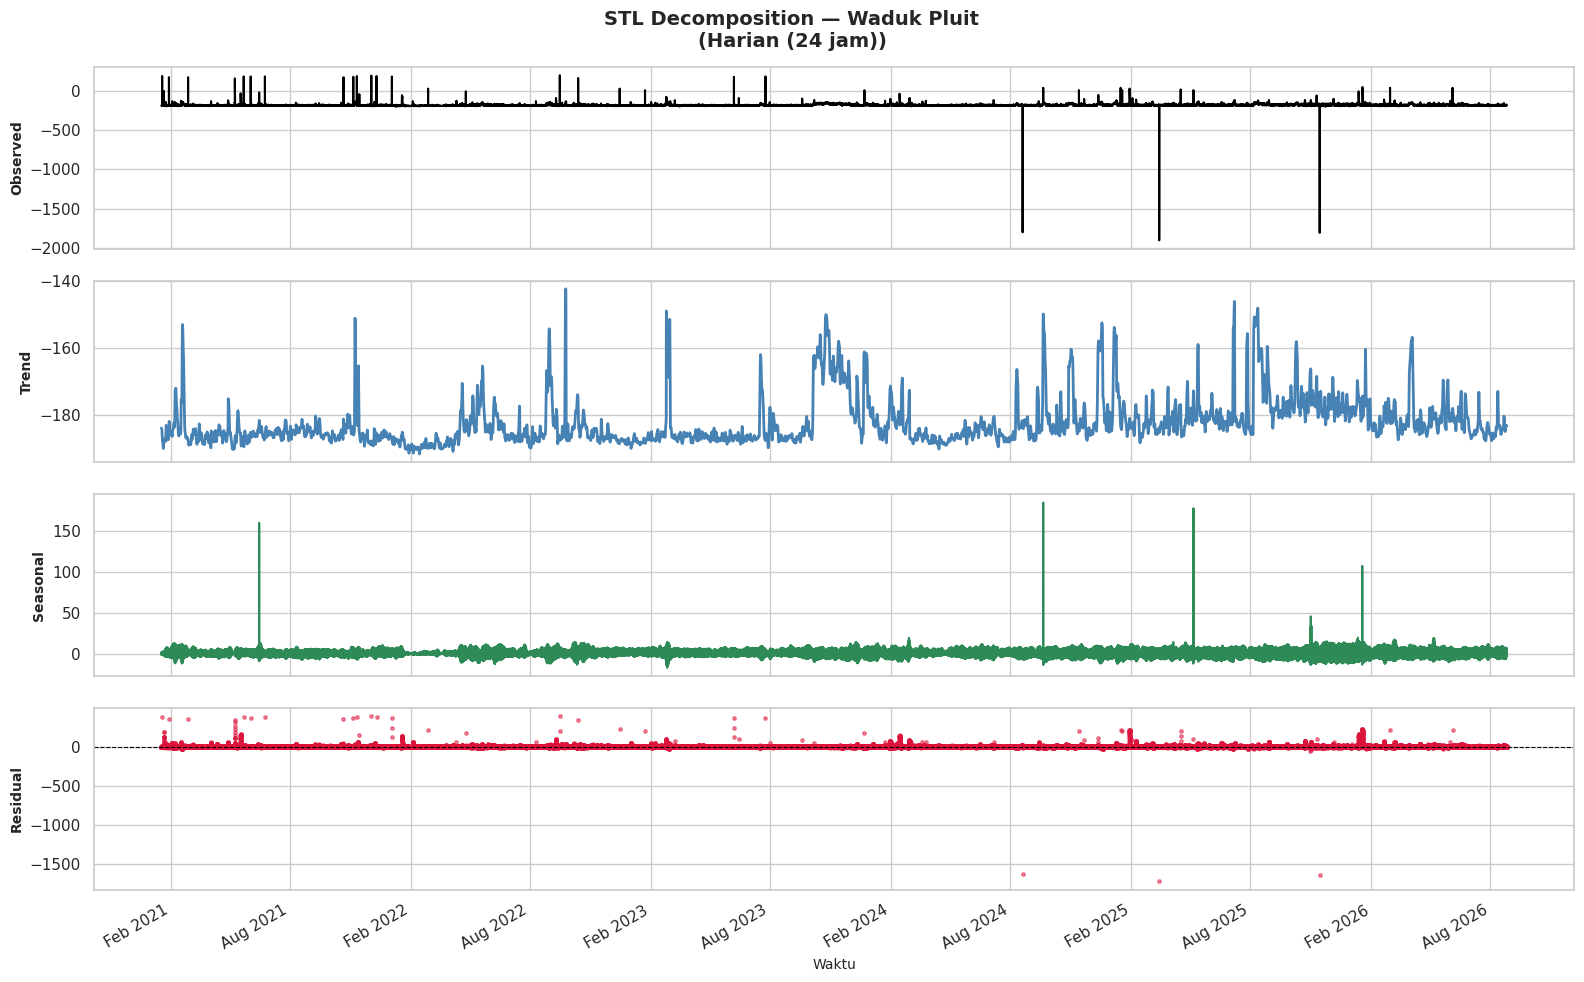

  Saved: stl_Waduk_Pluit_24h.png

  Periode: Mingguan (168 jam)
  Kekuatan Musiman (Fs): 0.594
  Kekuatan Tren    (Ft): 0.187


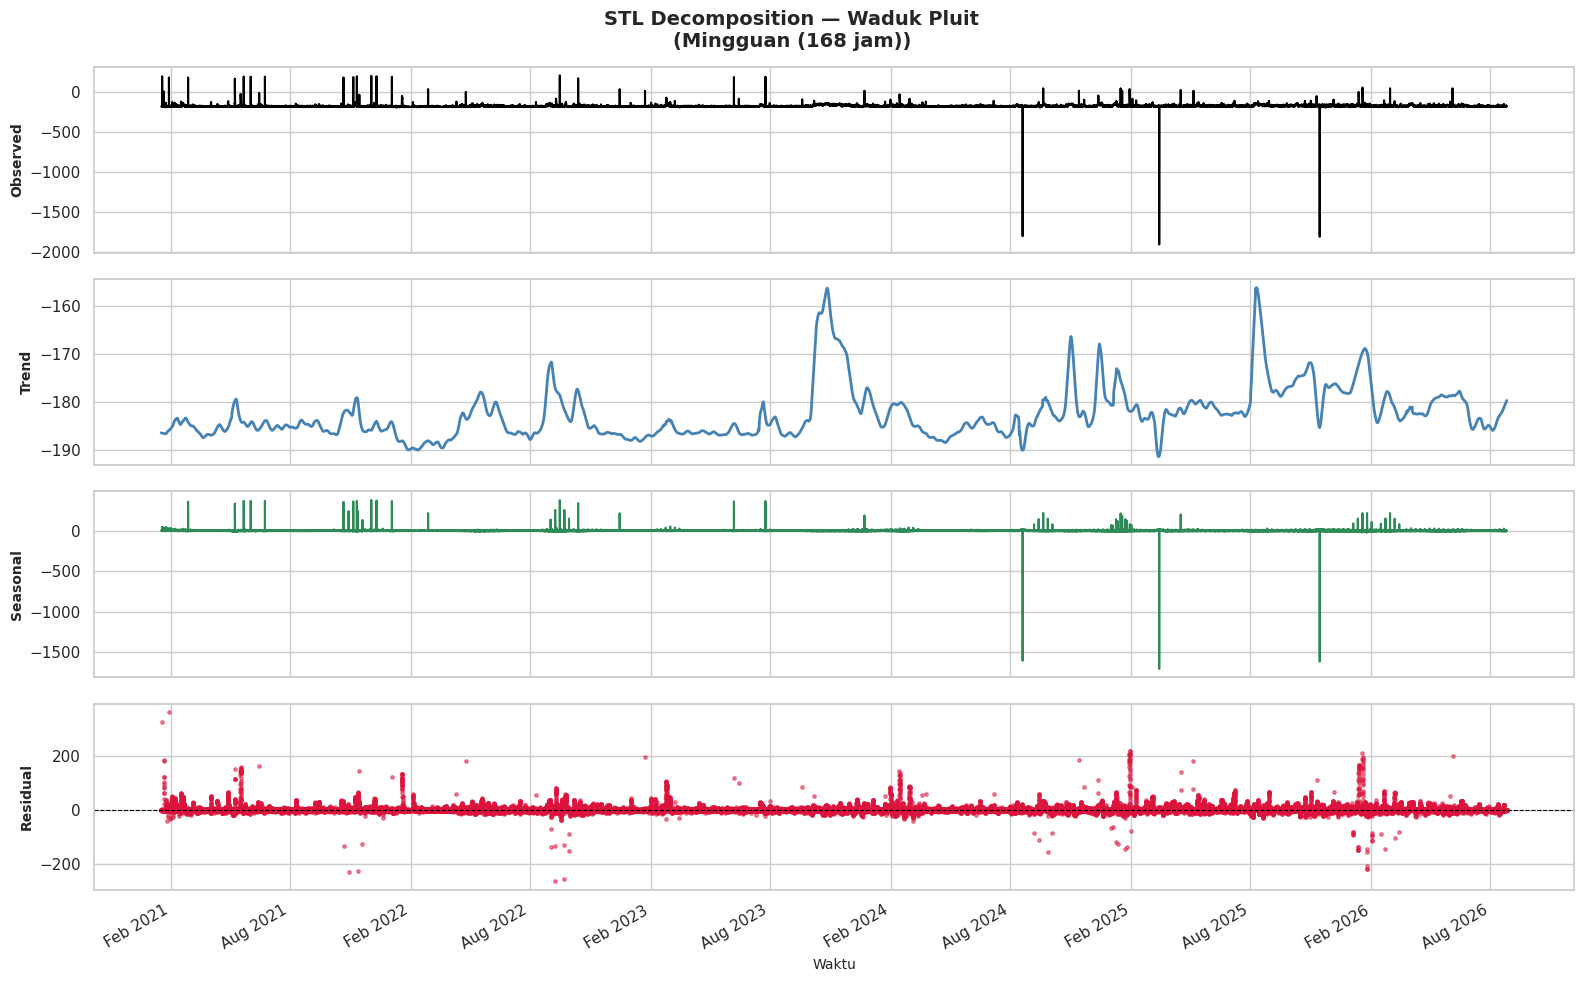

  Saved: stl_Waduk_Pluit_168h.png

  Periode: Bulanan (720 jam)
  Kekuatan Musiman (Fs): 0.248
  Kekuatan Tren    (Ft): 0.069


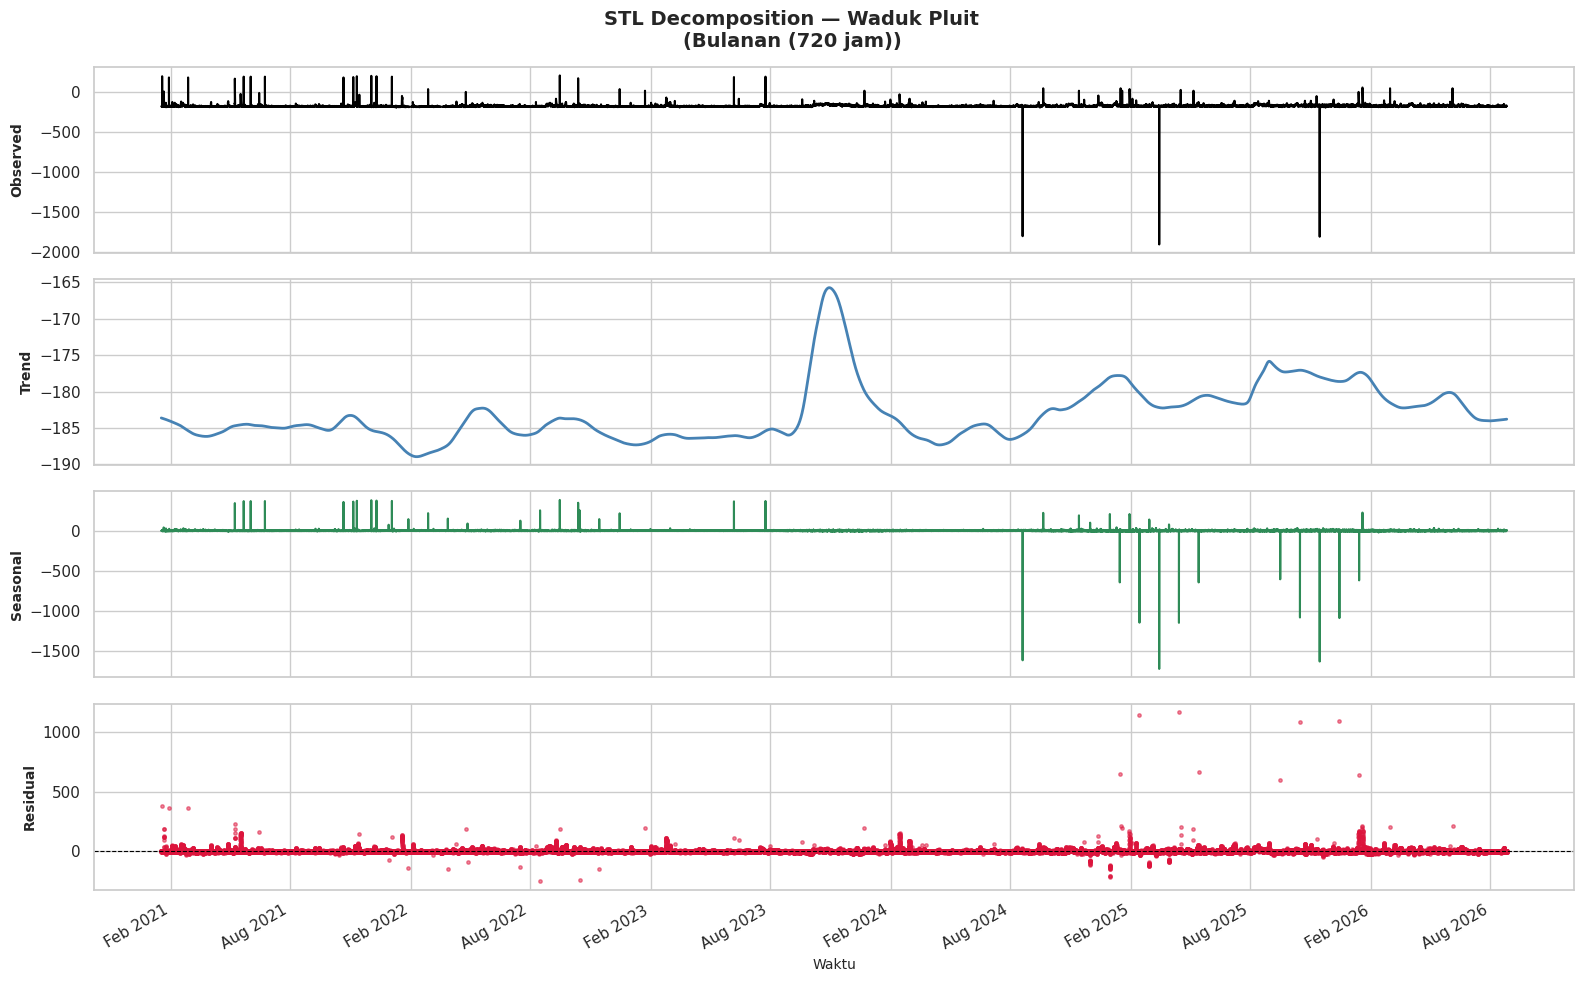

  Saved: stl_Waduk_Pluit_720h.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")

PERIODS = {
    'Harian (24 jam)'  : 24,
    'Mingguan (168 jam)': 24 * 7,
    'Bulanan (720 jam)': 24 * 30,
}

for station in REPRESENTATIVE_STATIONS:
    series = df_filled[station].dropna()

    print(f"\n{'='*60}")
    print(f"STL DECOMPOSITION — {station}")
    print(f"{'='*60}")

    for period_label, period_val in PERIODS.items():
        # Skip tahunan jika data tidak cukup (min 2 siklus)
        if len(series) < period_val * 2:
            print(f"  Skipping {period_label}: data tidak cukup untuk 2 siklus penuh.")
            continue

        stl = STL(series, period=period_val, robust=True)
        result = stl.fit()

        # Hitung kekuatan musiman dan tren (Wang et al. 2006)
        var_resid   = np.var(result.resid)
        var_seas    = np.var(result.seasonal + result.resid)
        var_trend   = np.var(result.trend + result.resid)

        seasonal_strength = max(0, 1 - var_resid / var_seas)
        trend_strength    = max(0, 1 - var_resid / var_trend)

        print(f"\n  Periode: {period_label}")
        print(f"  Kekuatan Musiman (Fs): {seasonal_strength:.3f}")
        print(f"  Kekuatan Tren    (Ft): {trend_strength:.3f}")

        # Plot
        fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
        fig.suptitle(
            f'STL Decomposition — {station}\n({period_label})',
            fontsize=14, fontweight='bold', y=0.98
        )

        components = [
            (result.observed, 'Observed', 'black', 1.5),
            (result.trend,    'Trend',    'steelblue', 2.0),
            (result.seasonal, 'Seasonal', 'seagreen', 1.5),
            (result.resid,    'Residual', 'crimson', 1.0),
        ]

        for ax, (data, label, color, lw) in zip(axes, components):
            if label == 'Residual':
                ax.scatter(data.index, data.values,
                           color=color, s=6, alpha=0.5)
                ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
            else:
                ax.plot(data.index, data.values,
                        color=color, linewidth=lw)
            ax.set_ylabel(label, fontsize=10, fontweight='bold')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

        axes[-1].set_xlabel('Waktu', fontsize=10)
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()

        fname = f"stl_{station.replace(' ', '_')}_{period_val}h.png"
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {fname}")


## **Stationarity Checks**

---

Stationarity checks are done using 2 methods :
- ACF and PACF plots for visualization and high level autocorrelation analysis
- ADF (Augmented Dickey-Fuller) for quantitative results


In order to check if we need differencing or not, ADF is employed to check whether the stations' values are independent or not.


In [ ]:
from statsmodels.tsa.stattools import adfuller

print("\n" + "="*60)
print("UJI STASIONERITAS — Augmented Dickey-Fuller (ADF)")
print("="*60)
print("H0: Terdapat unit root (series tidak stasioner)")
print("H1: Series stasioner")
print("Tolak H0 jika p-value < 0.05\n")

adf_rows = []

for station in df_filled.columns:
    series = df_filled[station].dropna()

    # ADF pada series asli
    adf_raw = adfuller(series, autolag='AIC')

    # ADF pada series differencing-1
    series_diff = series.diff().dropna()
    adf_diff = adfuller(series_diff, autolag='AIC')

    adf_rows.append({
        'Stasiun'             : station,
        'ADF Stat (Asli)'     : round(adf_raw[0], 4),
        'p-value (Asli)'      : round(adf_raw[1], 4),
        'Stasioner (Asli)'    : 'Ya' if adf_raw[1] < 0.05 else 'Tidak',
        'ADF Stat (Diff-1)'   : round(adf_diff[0], 4),
        'p-value (Diff-1)'    : round(adf_diff[1], 4),
        'Stasioner (Diff-1)'  : 'Ya' if adf_diff[1] < 0.05 else 'Tidak',
    })

adf_table = pd.DataFrame(adf_rows).set_index('Stasiun')
display(adf_table)
adf_table.to_csv('adf_stationarity_results.csv')
print("\nTabel disimpan ke: adf_stationarity_results.csv")



UJI STASIONERITAS — Augmented Dickey-Fuller (ADF)
H0: Terdapat unit root (series tidak stasioner)
H1: Series stasioner
Tolak H0 jika p-value < 0.05



,ADF Stat (Asli),p-value (Asli),Stasioner (Asli),ADF Stat (Diff-1),p-value (Diff-1),Stasioner (Diff-1)
Stasiun,,,,,,
Bendung Katulampa,-12.1665,0.0,Ya,-47.2625,0.0,Ya
Pos Angke Hulu,-18.5917,0.0,Ya,-39.8754,0.0,Ya
Pos Cipinang Hulu,-15.6873,0.0,Ya,-47.3245,0.0,Ya
Pos Depok,-11.4384,0.0,Ya,-49.2631,0.0,Ya
Pos Krukut Hulu,-17.9823,0.0,Ya,-42.2920,0.0,Ya
Pos Pesanggrahan,-17.4596,0.0,Ya,-41.6311,0.0,Ya
Pos Sunter Hulu,-16.4201,0.0,Ya,-39.7733,0.0,Ya
Waduk Pluit,-20.8403,0.0,Ya,-51.4551,0.0,Ya



Tabel disimpan ke: adf_stationarity_results.csv


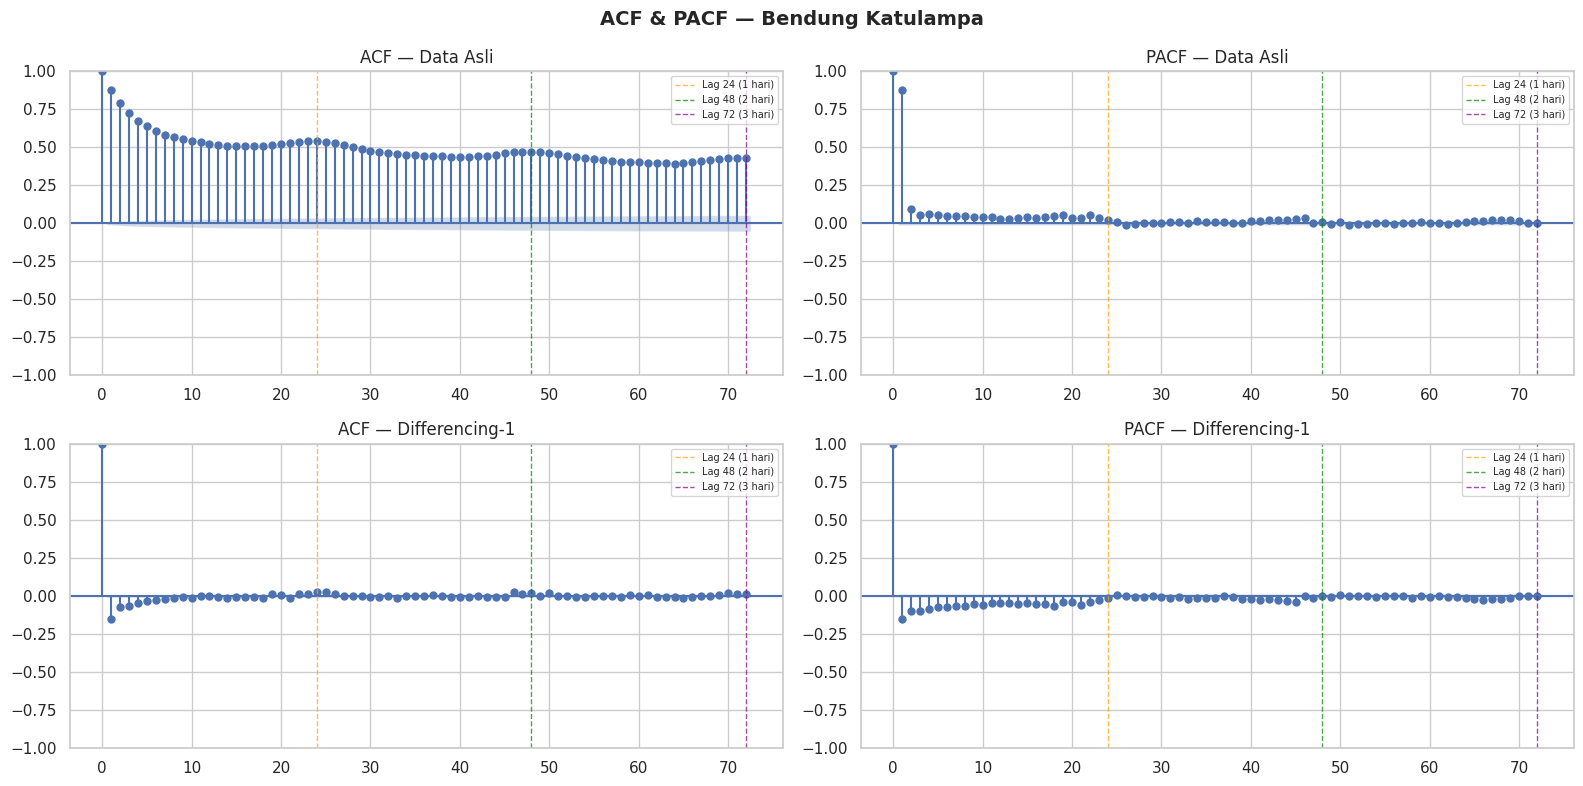

Saved: acf_pacf_Bendung_Katulampa.png


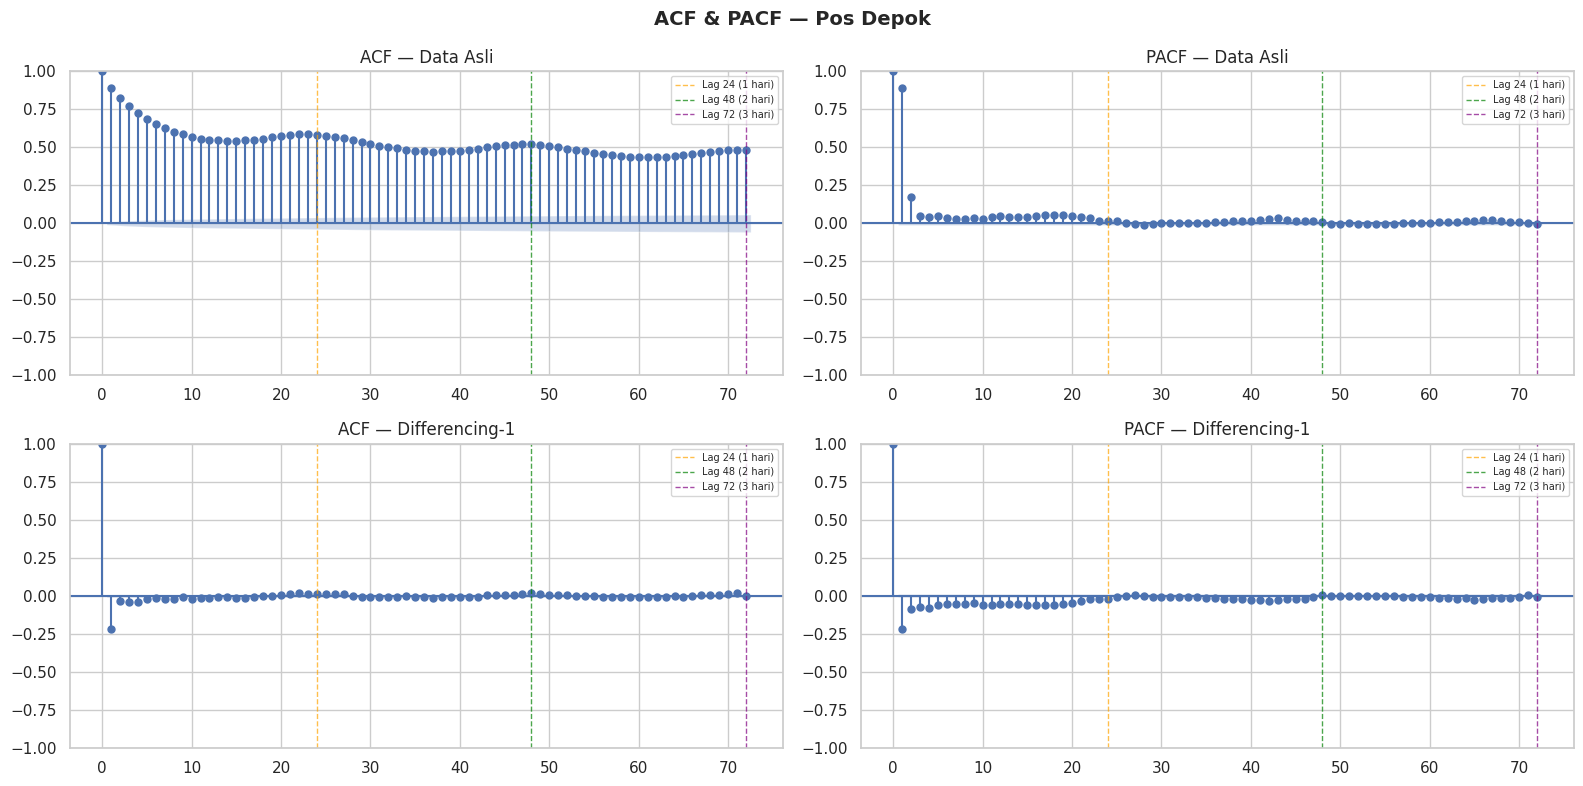

Saved: acf_pacf_Pos_Depok.png


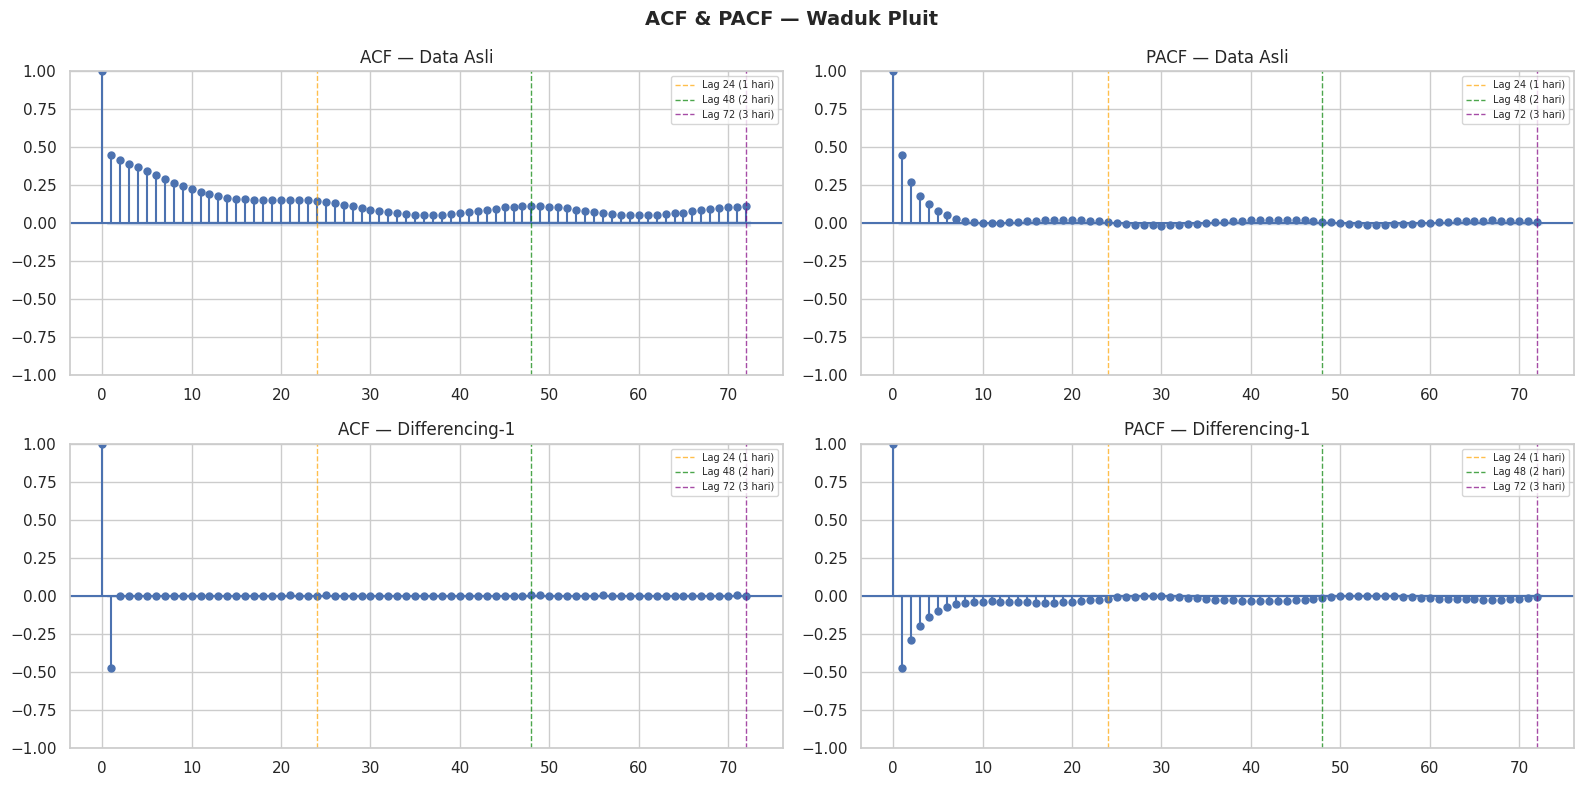

Saved: acf_pacf_Waduk_Pluit.png

Interpretasi ACF/PACF untuk justifikasi lookback window:
- Lag signifikan terakhir pada ACF → upper bound window size LSTM/GRU
- Spike pada PACF lag 24/48 → konfirmasi musiman harian/2-harian
- Pola ACF meluruh cepat setelah differencing → series menjadi stasioner


In [ ]:
LAGS = 72  # 72 jam = 3 hari ke belakang

for station in REPRESENTATIVE_STATIONS:
    series_raw  = df_filled[station].dropna()
    series_diff = series_raw.diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(
        f'ACF & PACF — {station}',
        fontsize=14, fontweight='bold'
    )

    # Baris atas: data asli
    plot_acf( series_raw,  lags=LAGS, ax=axes[0][0], alpha=0.05)
    plot_pacf(series_raw,  lags=LAGS, ax=axes[0][1], alpha=0.05, method='ywm')
    axes[0][0].set_title('ACF — Data Asli')
    axes[0][1].set_title('PACF — Data Asli')

    # Baris bawah: differenced
    plot_acf( series_diff, lags=LAGS, ax=axes[1][0], alpha=0.05)
    plot_pacf(series_diff, lags=LAGS, ax=axes[1][1], alpha=0.05, method='ywm')
    axes[1][0].set_title('ACF — Differencing-1')
    axes[1][1].set_title('PACF — Differencing-1')

    # Anotasi lag penting
    for ax in axes.flat:
        ax.axvline(24,  color='orange', linestyle='--',
                   linewidth=1, alpha=0.7, label='Lag 24 (1 hari)')
        ax.axvline(48,  color='green',  linestyle='--',
                   linewidth=1, alpha=0.7, label='Lag 48 (2 hari)')
        ax.axvline(72,  color='purple', linestyle='--',
                   linewidth=1, alpha=0.7, label='Lag 72 (3 hari)')
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()

    fname = f"acf_pacf_{station.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

print("\nInterpretasi ACF/PACF untuk justifikasi lookback window:")
print("- Lag signifikan terakhir pada ACF → upper bound window size LSTM/GRU")
print("- Spike pada PACF lag 24/48 → konfirmasi musiman harian/2-harian")
print("- Pola ACF meluruh cepat setelah differencing → series menjadi stasioner")

## Correlation Between Stations + Dendrogram

---

This plot will help us understand the correlation between stations, specifically to understand water flows (hulu-hilir).

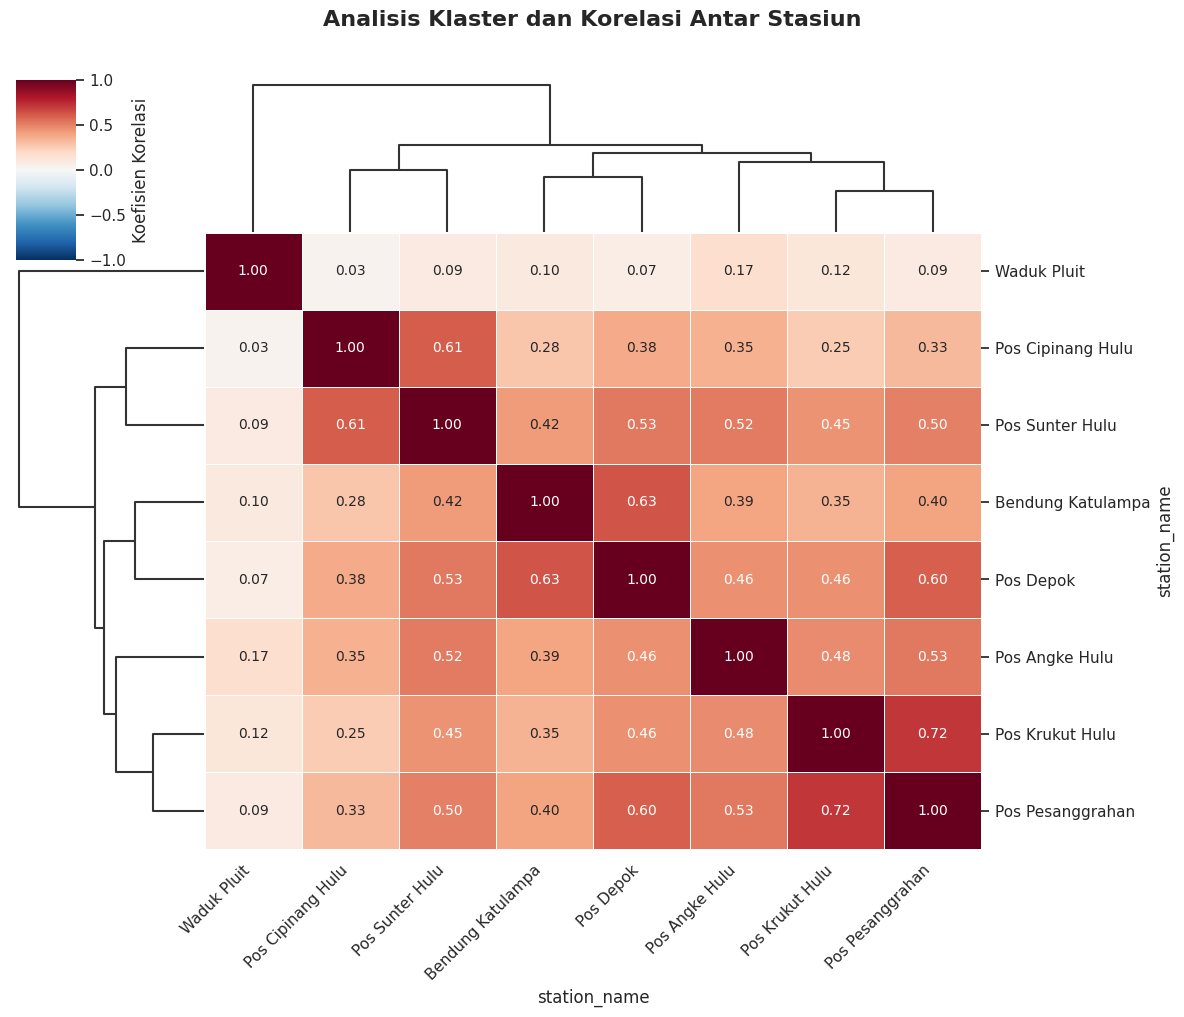

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung korelasi
corr_plot = df_filled.corr(numeric_only=True)

# 2. Buat Clustermap (figsize masuk ke sini)
g = sns.clustermap(
    corr_plot,
    figsize=(12, 10),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",        # Rekomendasi: RdBu_r atau vlag terlihat lebih profesional untuk tesis
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Koefisien Korelasi"},
    annot_kws={"size": 10},
    tree_kws={"linewidths": 1.5} # Mempertegas garis dendrogram
)

# 3. Menambahkan Judul (gunakan g.fig.suptitle agar posisinya pas)
g.fig.suptitle('Analisis Klaster dan Korelasi Antar Stasiun',
               fontsize=16, fontweight='bold', y=1.05)

# 4. Merapikan rotasi teks pada sumbu X dan Y di dalam heatmap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)


# Tampilkan plot
plt.show()

## **Feature Engineering**

---


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.preprocessing import MinMaxScaler

try:
    import holidays
    _HAS_HOLIDAYS = True
except ImportError:
    _HAS_HOLIDAYS = False
    print("[WARN] install dulu: pip install holidays")

In [ ]:
CALENDAR_COLS = ["hour", "month", "day_of_week", "is_weekend", "is_holiday", "is_rainy_season"]

def add_calendar_features(df):
    df = df.copy()
    idx = df.index

    df["hour"]        = idx.hour
    df["month"]       = idx.month
    df["day_of_week"] = idx.dayofweek      # 0=Mon, 6=Sun
    df["is_weekend"]  = (idx.dayofweek >= 5).astype(int)

    if _HAS_HOLIDAYS:
        years = idx.year.unique().tolist()
        id_hol = holidays.Indonesia(years=years)
        df["is_holiday"] = idx.normalize().isin(id_hol).astype(int)
    else:
        df["is_holiday"] = 0  # isi manual kalau perlu

    # Musim hujan Jakarta: Nov–Apr = 0, Mei–Okt = 1
    df["is_rainy_season"] = df["month"].apply(lambda m: 0 if m in [11, 12, 1, 2, 3, 4] else 1)

    return df

df_fe = add_calendar_features(df_filled)
print("Shape setelah calendar features:", df_fe.shape)
print("Kolom baru:", CALENDAR_COLS)
df_fe.head(3)

Shape setelah calendar features: (49152, 14)
Kolom baru: ['hour', 'month', 'day_of_week', 'is_weekend', 'is_holiday', 'is_rainy_season']


/tmp/ipykernel_711/1240466146.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = idx.normalize().isin(id_hol).astype(int)


station_name,Bendung Katulampa,Pos Angke Hulu,Pos Cipinang Hulu,Pos Depok,Pos Krukut Hulu,Pos Pesanggrahan,Pos Sunter Hulu,Waduk Pluit,hour,month,day_of_week,is_weekend,is_holiday,is_rainy_season
datetime,,,,,,,,,,,,,,
2021-01-16 00:00:00,20.0,40.0,75.0,90.0,10.0,55.0,70.0,NaN,0,1,5,1,0,0
2021-01-16 01:00:00,20.0,40.0,80.0,90.0,10.0,55.0,70.0,NaN,1,1,5,1,0,0
2021-01-16 02:00:00,20.0,40.0,80.0,90.0,10.0,55.0,70.0,NaN,2,1,5,1,0,0


In [ ]:
# Cek distribusi setiap fitur
for col in CALENDAR_COLS:
    unique_vals = sorted(df_fe[col].unique())
    print(f"{col:15s}: {len(unique_vals)} nilai unik — min={min(unique_vals)}, max={max(unique_vals)}")

# Cek is_holiday
n_holiday = df_fe["is_holiday"].sum()
print(f"\nTotal jam hari libur: {n_holiday:,} ({n_holiday/len(df_fe)*100:.2f}%)")

# Cek season
print(f"\nDistribusi season:\n{df_fe['is_rainy_season'].value_counts().rename({0:'Wet (Nov-Apr)', 1:'Dry (May-Oct)'})}")

hour           : 24 nilai unik — min=0, max=23
month          : 12 nilai unik — min=1, max=12
day_of_week    : 7 nilai unik — min=0, max=6
is_weekend     : 2 nilai unik — min=0, max=1
is_holiday     : 2 nilai unik — min=0, max=1
is_rainy_season: 2 nilai unik — min=0, max=1

Total jam hari libur: 2,352 (4.79%)

Distribusi season:
is_rainy_season
Dry (May-Oct)    24888
Wet (Nov-Apr)    24264
Name: count, dtype: int64


In [ ]:
# Cell terakhir notebook FE
os.makedirs("artifacts", exist_ok=True)
df_fe.to_parquet("artifacts/df_fe.parquet")
print(f"Saved: artifacts/df_fe.parquet {df_fe.shape}")
print(f"Kolom: {df_fe.columns.tolist()}")

Saved: artifacts/df_fe.parquet (49152, 14)
Kolom: ['Bendung Katulampa', 'Pos Angke Hulu', 'Pos Cipinang Hulu', 'Pos Depok', 'Pos Krukut Hulu', 'Pos Pesanggrahan', 'Pos Sunter Hulu', 'Waduk Pluit', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_holiday', 'is_rainy_season']
